# PySQReg — Prueba con datos reales de Medellín

Índice Multidimensional de Calidad de Vida (IMCV) por comunas, 2011-2018.  
Fuente: MEData — Alcaldía de Medellín.

In [72]:
import numpy as np
import pandas as pd
import geopandas as gpd
import libpysal
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec

from pysqreg import QuantSAR, moran_test, plot_moran, fit_quantile_process, plot_rho_path

# ═══════════════════════════════════════════════════════════════════════════
#  Premium dark palette — slide-ready
# ═══════════════════════════════════════════════════════════════════════════
BG      = '#0B0E14'
CARD    = '#12161F'
EDGE    = '#1E2533'
FG      = '#E8ECF1'
GRAY    = '#6B7B8D'
ACCENT  = '#5B9CF6'
GREEN   = '#4ADE80'
RED     = '#FB7185'
ORANGE  = '#FBBF24'
PURPLE  = '#C084FC'
TEAL    = '#2DD4BF'
PINK    = '#F472B6'
CYAN    = '#22D3EE'
SLATE   = '#94A3B8'

PALETTE = [ACCENT, TEAL, ORANGE, PURPLE, PINK, GREEN, RED]

# ── Global rcParams for presentation quality ──
plt.rcParams.update({
    'figure.facecolor':     BG,
    'figure.dpi':           180,
    'savefig.dpi':          300,
    'savefig.facecolor':    BG,
    'axes.facecolor':       CARD,
    'axes.edgecolor':       EDGE,
    'axes.labelcolor':      FG,
    'axes.titlecolor':      FG,
    'text.color':           FG,
    'xtick.color':          SLATE,
    'ytick.color':          SLATE,
    'grid.color':           EDGE,
    'grid.alpha':           0.35,
    'grid.linewidth':       0.4,
    'font.family':          'sans-serif',
    'font.sans-serif':      ['Inter', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'font.size':            11,
    'axes.titlesize':       15,
    'axes.labelsize':       12,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'axes.grid':            True,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.linewidth':       0.6,
    'legend.facecolor':     CARD,
    'legend.edgecolor':     EDGE,
    'legend.labelcolor':    FG,
    'legend.fontsize':      10,
    'legend.framealpha':    0.95,
    'lines.linewidth':      2.0,
    'patch.linewidth':      0,
})


def glow(ax, x, y, color, lw=2.5, **kw):
    """Línea con efecto glow neón — triple capa."""
    ax.plot(x, y, color=color, lw=lw * 4, alpha=0.05, solid_capstyle='round', **kw)
    ax.plot(x, y, color=color, lw=lw * 2, alpha=0.15, solid_capstyle='round', **kw)
    return ax.plot(x, y, color=color, lw=lw, alpha=1.0, solid_capstyle='round', **kw)[0]


def watermark(fig, x=0.98, y=0.02):
    fig.text(x, y, 'PySQReg', fontsize=9, color=GRAY,
             alpha=0.25, ha='right', va='bottom',
             fontstyle='italic', fontweight='light')


def style_colorbar(cbar, label=''):
    """Estilizar colorbar para dark mode."""
    cbar.outline.set_edgecolor(EDGE)
    cbar.ax.tick_params(colors=SLATE, length=3, width=0.5)
    if label:
        cbar.set_label(label, color=FG, fontsize=10, labelpad=8)


def add_subtitle(ax, text, color=SLATE, fontsize=10):
    """Subtítulo bajo el título principal."""
    ax.text(0.5, 1.02, text, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=fontsize,
            color=color, fontstyle='italic')


# Quad colors for Moran plots
quad_colors = {'HH': RED, 'LL': ACCENT, 'LH': PURPLE, 'HL': ORANGE}

## 1. Cargar datos

In [73]:
# IMCV agregado por comuna y año
imcv = pd.read_csv('data_spatial.csv')
print(f'Shape: {imcv.shape}')
imcv.head()

Shape: (192, 18)


,varcharidcomunafk,intaño,decentornocalidadvivienda,decaccesoserviciospublicos,decmedioambiente,decescolaridad,decdescolarizacion,decmovilidad,deccapitalfisicohogar,decparticipacion,declibertadseguridad,decvulnerabilida,decsalud,dectrabajo,decrecreacion,decpercepcioncalidadvida,decingresos,decimcv
0,1,2011,1.380000,3.570000,2.510000,1.470000,3.880000,1.370000,3.310000,1.100000,1.840000,6.350000,2.550000,0.510000,0.190000,1.2500,0.780000,32.06
1,1,2012,1.390000,3.610000,2.280000,1.590000,3.900000,1.350000,3.680000,0.810000,1.590000,6.900000,2.620000,0.520000,0.330000,1.4000,0.960000,32.88
2,1,2013,1.390000,3.570000,2.250000,1.580000,3.910000,1.400000,3.830000,0.960000,1.850000,6.690000,2.650000,0.570000,0.050000,1.3600,1.100000,33.27
3,1,2014,1.411854,3.589982,2.121174,1.603315,3.975634,1.295639,3.739863,1.000021,1.599736,6.952948,2.569105,0.552032,0.058456,1.2784,1.121182,32.82
4,1,2015,1.237000,3.607000,1.753000,1.811000,4.146000,1.262000,3.667000,1.098000,1.729000,7.018000,3.041000,0.485000,0.067000,1.3550,1.039000,33.53


In [74]:
# GeoJSON de comunas
gdf = gpd.read_file('Comunas_Medellin.geojson')
print(f'Comunas en GeoJSON: {len(gdf)}')
gdf[['Numero_Comuna', 'Nombre_Comuna']].sort_values('Numero_Comuna')

Comunas en GeoJSON: 16


,Numero_Comuna,Nombre_Comuna
0,1,Popular
1,2,Santa Cruz
2,3,Manrique
3,4,Aranjuez
4,5,Castilla
5,6,Doce de Octubre
6,7,Robledo
7,8,Villa Hermosa
8,9,Buenos Aires
9,10,La Candelaria


## 2. Preparar corte transversal (2018) — solo comunas urbanas

In [75]:
# Filtrar solo comunas 1-16, año 2018
df = imcv[(imcv['intaño'] == 2018) & (imcv['varcharidcomunafk'] <= 16)].copy()
df = df.sort_values('varcharidcomunafk').reset_index(drop=True)
print(f'Observaciones: {len(df)} comunas')
df

Observaciones: 16 comunas


,varcharidcomunafk,intaño,decentornocalidadvivienda,decaccesoserviciospublicos,decmedioambiente,decescolaridad,decdescolarizacion,decmovilidad,deccapitalfisicohogar,decparticipacion,declibertadseguridad,decvulnerabilida,decsalud,dectrabajo,decrecreacion,decpercepcioncalidadvida,decingresos,decimcv
0,1,2018,1.427586,3.542790,2.248087,1.733398,4.036880,1.365071,3.939316,1.123546,1.738997,6.956276,3.052389,0.543446,0.067538,1.427129,1.381867,34.75
1,2,2018,2.010603,3.756792,2.264237,1.811498,4.111237,1.384597,4.339784,1.154220,1.788600,8.004234,2.955356,0.545036,0.033134,1.435153,1.408820,37.08
2,3,2018,1.999424,3.716607,2.474931,1.817463,4.168186,1.336379,4.397909,1.147216,1.707909,8.133909,3.026783,0.465437,0.075831,1.394858,1.491256,37.45
3,4,2018,3.472985,3.907017,2.437901,2.012752,4.216471,1.511463,5.611763,1.317054,1.786408,10.664424,3.190290,0.512171,0.098397,1.492067,1.661355,44.12
4,5,2018,4.292559,4.042632,2.641734,2.232169,4.293630,1.581730,6.321392,1.340240,1.732871,12.131417,3.360782,0.595635,0.102985,1.508351,1.887858,48.06
5,6,2018,2.559501,4.046093,2.569693,1.908983,4.152571,1.523866,4.964232,1.275591,1.762197,9.173766,3.151904,0.489709,0.083559,1.456291,1.547543,40.79
6,7,2018,3.528548,4.024895,2.891663,2.526757,4.210995,1.464845,5.917433,1.381240,1.623602,10.804378,3.537592,0.522670,0.086006,1.564367,1.833860,46.12
7,8,2018,2.298893,3.712965,2.467152,2.004887,4.189874,1.436117,4.897329,1.244748,1.754596,8.846615,3.112983,0.493799,0.069097,1.479704,1.528454,39.67
8,9,2018,4.395768,4.002424,2.911755,2.515093,4.303578,1.626185,6.639969,1.353917,1.855967,12.388279,3.624136,0.561551,0.069259,1.608569,1.986330,49.91
9,10,2018,6.585980,3.999964,2.553831,2.998941,4.390195,1.663262,7.524407,1.505607,1.575726,15.507725,3.655595,0.574415,0.137892,1.581351,2.315546,56.42


In [76]:
# Merge con geometría
gdf_sorted = gdf.sort_values('Numero_Comuna').reset_index(drop=True)
df_geo = gdf_sorted.merge(
    df, left_on='Numero_Comuna', right_on='varcharidcomunafk', how='inner'
)
df_geo = gpd.GeoDataFrame(df_geo, geometry='geometry')
print(f'Registros después del merge: {len(df_geo)}')

Registros después del merge: 16


## 3. Mapa del IMCV por comuna

/var/folders/t1/z9wpfgts6hg2hkzn2rwjw6q40000gn/T/ipykernel_14486/2228145507.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


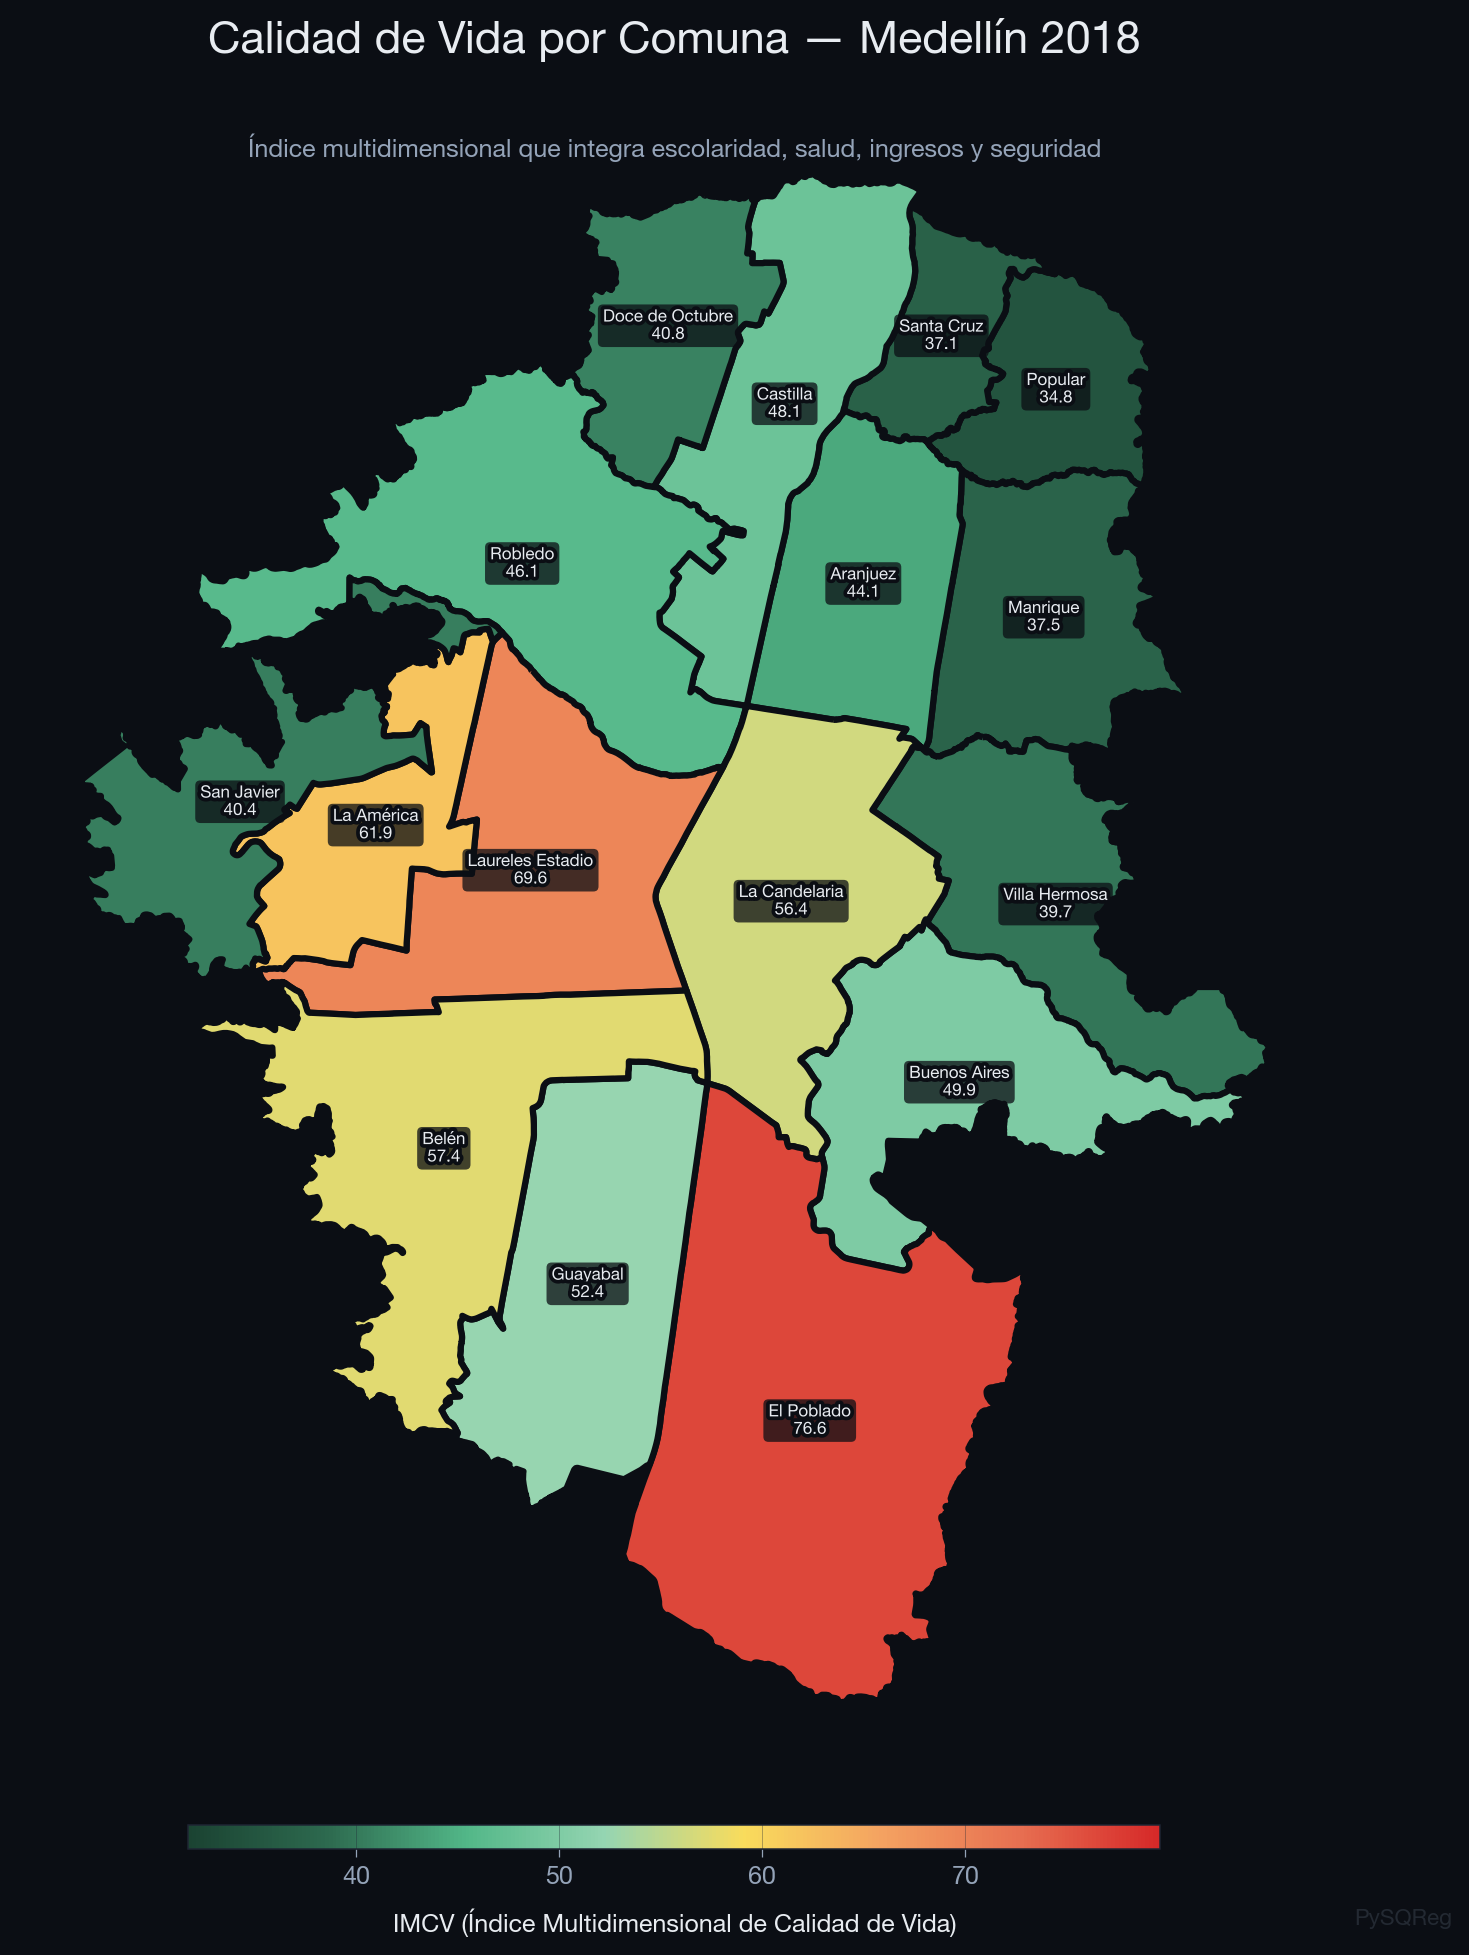

In [77]:
# ── Mapa IMCV por comuna ──
fig, ax = plt.subplots(figsize=(9, 11), facecolor=BG)
ax.set_facecolor(BG)

# Palette: dark-friendly diverging green-gold
cmap = mcolors.LinearSegmentedColormap.from_list(
    'imcv', ['#1B4332', '#2D6A4F', '#52B788', '#95D5B2',
             '#F9DC5C', '#F4A261', '#E76F51', '#D62828'], N=256)
vmin, vmax = df_geo['decimcv'].min() - 3, df_geo['decimcv'].max() + 3
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

df_geo.plot(
    column='decimcv', cmap=cmap, ax=ax, norm=norm,
    edgecolor=BG, linewidth=2.5,
)

# Etiquetas con nombre de comuna y valor
for _, row in df_geo.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    val = row['decimcv']
    ax.annotate(
        f"{row['Nombre_Comuna']}\n{val:.1f}",
        xy=(cx, cy), ha='center', va='center',
        fontsize=6.8, fontweight='bold', color=FG,
        path_effects=[pe.withStroke(linewidth=3, foreground=BG)],
        bbox=dict(boxstyle='round,pad=0.3', fc=BG, ec=EDGE, alpha=0.75),
    )

# Colorbar horizontal
cbar_ax = fig.add_axes([0.2, 0.06, 0.6, 0.012])
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm),
                     cax=cbar_ax, orientation='horizontal')
style_colorbar(cbar, 'IMCV (Índice Multidimensional de Calidad de Vida)')

ax.set_title('Calidad de Vida por Comuna — Medellín 2018',
             fontsize=18, fontweight='bold', color=FG, pad=18)
ax.text(0.5, 0.965, 'Índice multidimensional que integra escolaridad, salud, ingresos y seguridad',
        transform=ax.transAxes, ha='center', fontsize=10, color=SLATE, fontstyle='italic')
ax.set_axis_off()
watermark(fig)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## 4. Matriz de pesos espaciales (contigüidad Queen)

/var/folders/t1/z9wpfgts6hg2hkzn2rwjw6q40000gn/T/ipykernel_14486/1994436403.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


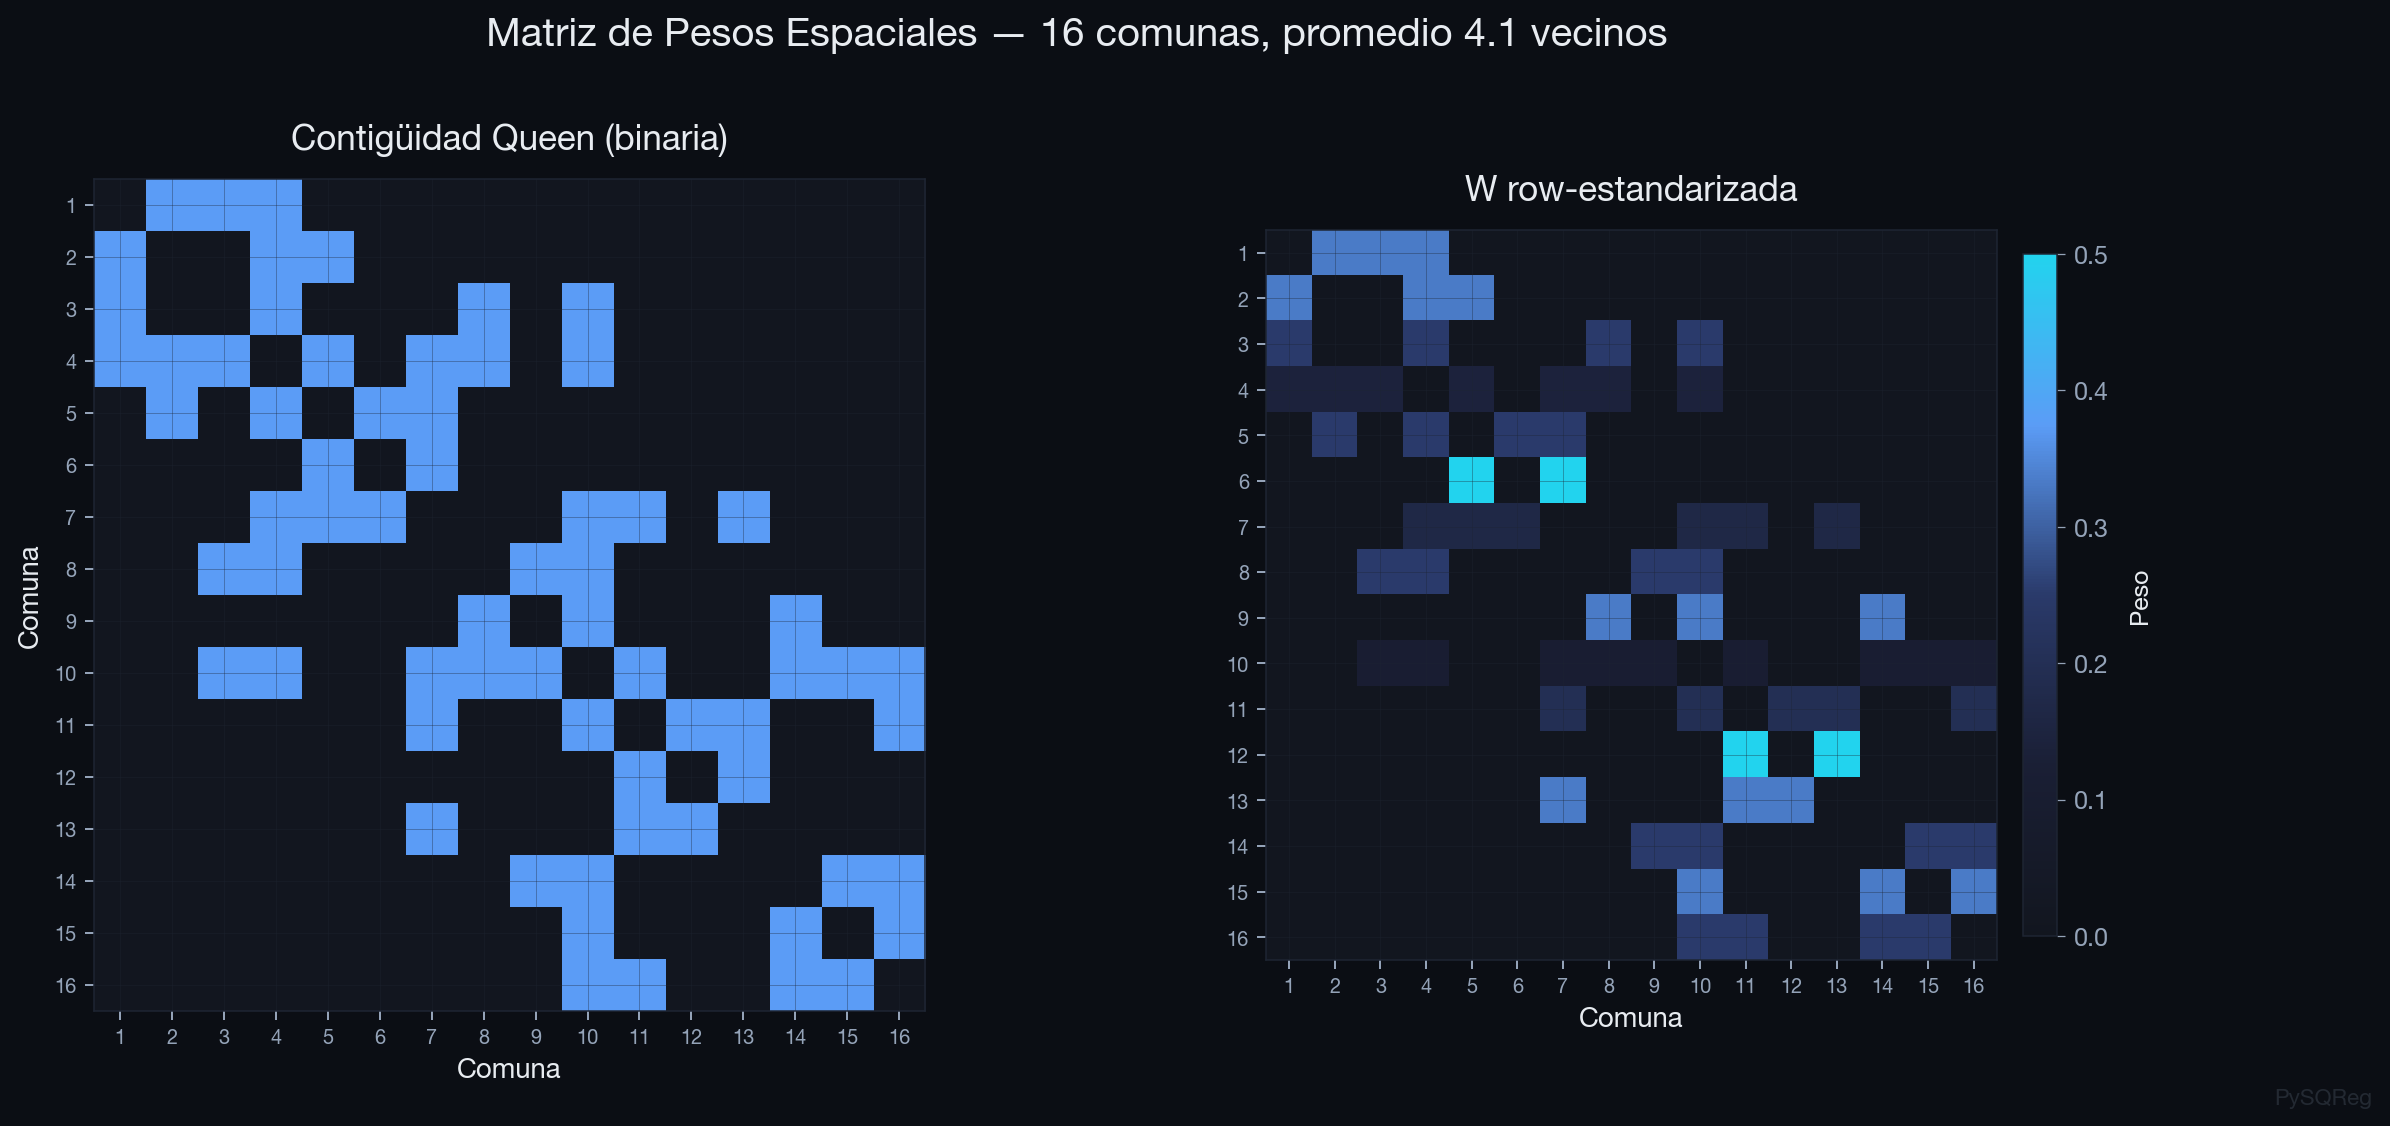

In [78]:
# Construir W con libpysal
w = libpysal.weights.Queen.from_dataframe(df_geo, use_index=False)
w.transform = 'r'
W = w.full()[0]

# ── Visualizar W como heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG,
                         gridspec_kw={'wspace': 0.35})

comuna_ids = df_geo['Numero_Comuna'].values

# ─ Panel 1: Contigüidad binaria ─
W_binary = (W > 0).astype(float)
cmap_bin = mcolors.LinearSegmentedColormap.from_list('bin', [CARD, ACCENT], N=2)
im0 = axes[0].imshow(W_binary, cmap=cmap_bin, interpolation='nearest', aspect='equal')
axes[0].set_title('Contigüidad Queen (binaria)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Comuna', fontsize=11)
axes[0].set_ylabel('Comuna', fontsize=11)
axes[0].set_xticks(range(16))
axes[0].set_yticks(range(16))
axes[0].set_xticklabels(comuna_ids, fontsize=8)
axes[0].set_yticklabels(comuna_ids, fontsize=8)
for spine in axes[0].spines.values():
    spine.set_visible(True)
    spine.set_color(EDGE)

# ─ Panel 2: W row-standardized ─
cmap_w = mcolors.LinearSegmentedColormap.from_list(
    'wmat', [CARD, '#1A1F35', '#2A3A6A', ACCENT, CYAN], N=256)
im1 = axes[1].imshow(W, cmap=cmap_w, interpolation='nearest', aspect='equal')
axes[1].set_title('W row-estandarizada', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Comuna', fontsize=11)
axes[1].set_xticks(range(16))
axes[1].set_yticks(range(16))
axes[1].set_xticklabels(comuna_ids, fontsize=8)
axes[1].set_yticklabels(comuna_ids, fontsize=8)
for spine in axes[1].spines.values():
    spine.set_visible(True)
    spine.set_color(EDGE)

cbar = fig.colorbar(im1, ax=axes[1], shrink=0.82, pad=0.03)
style_colorbar(cbar, 'Peso')

fig.suptitle(f'Matriz de Pesos Espaciales — {w.n} comunas, '
             f'promedio {w.mean_neighbors:.1f} vecinos',
             fontsize=16, fontweight='bold', y=1.03, color=FG)
watermark(fig)
plt.tight_layout()
plt.show()

## 5. Test de Moran — ¿hay autocorrelación espacial?

In [79]:
y = df_geo['decimcv'].values
result = moran_test(y, W)
result.summary()

  Moran's I Test for Spatial Autocorrelation
  Moran's I statistic :  0.330445
  Expected value E[I] : -0.066667
  Variance Var[I]     :  0.023549
  Z-score             :  2.5878
  p-value (two-sided) :  0.009660
  Assumption          : randomization
  N                   : 16
-------------------------------------------------------
  Significant POSITIVE spatial autocorrelation


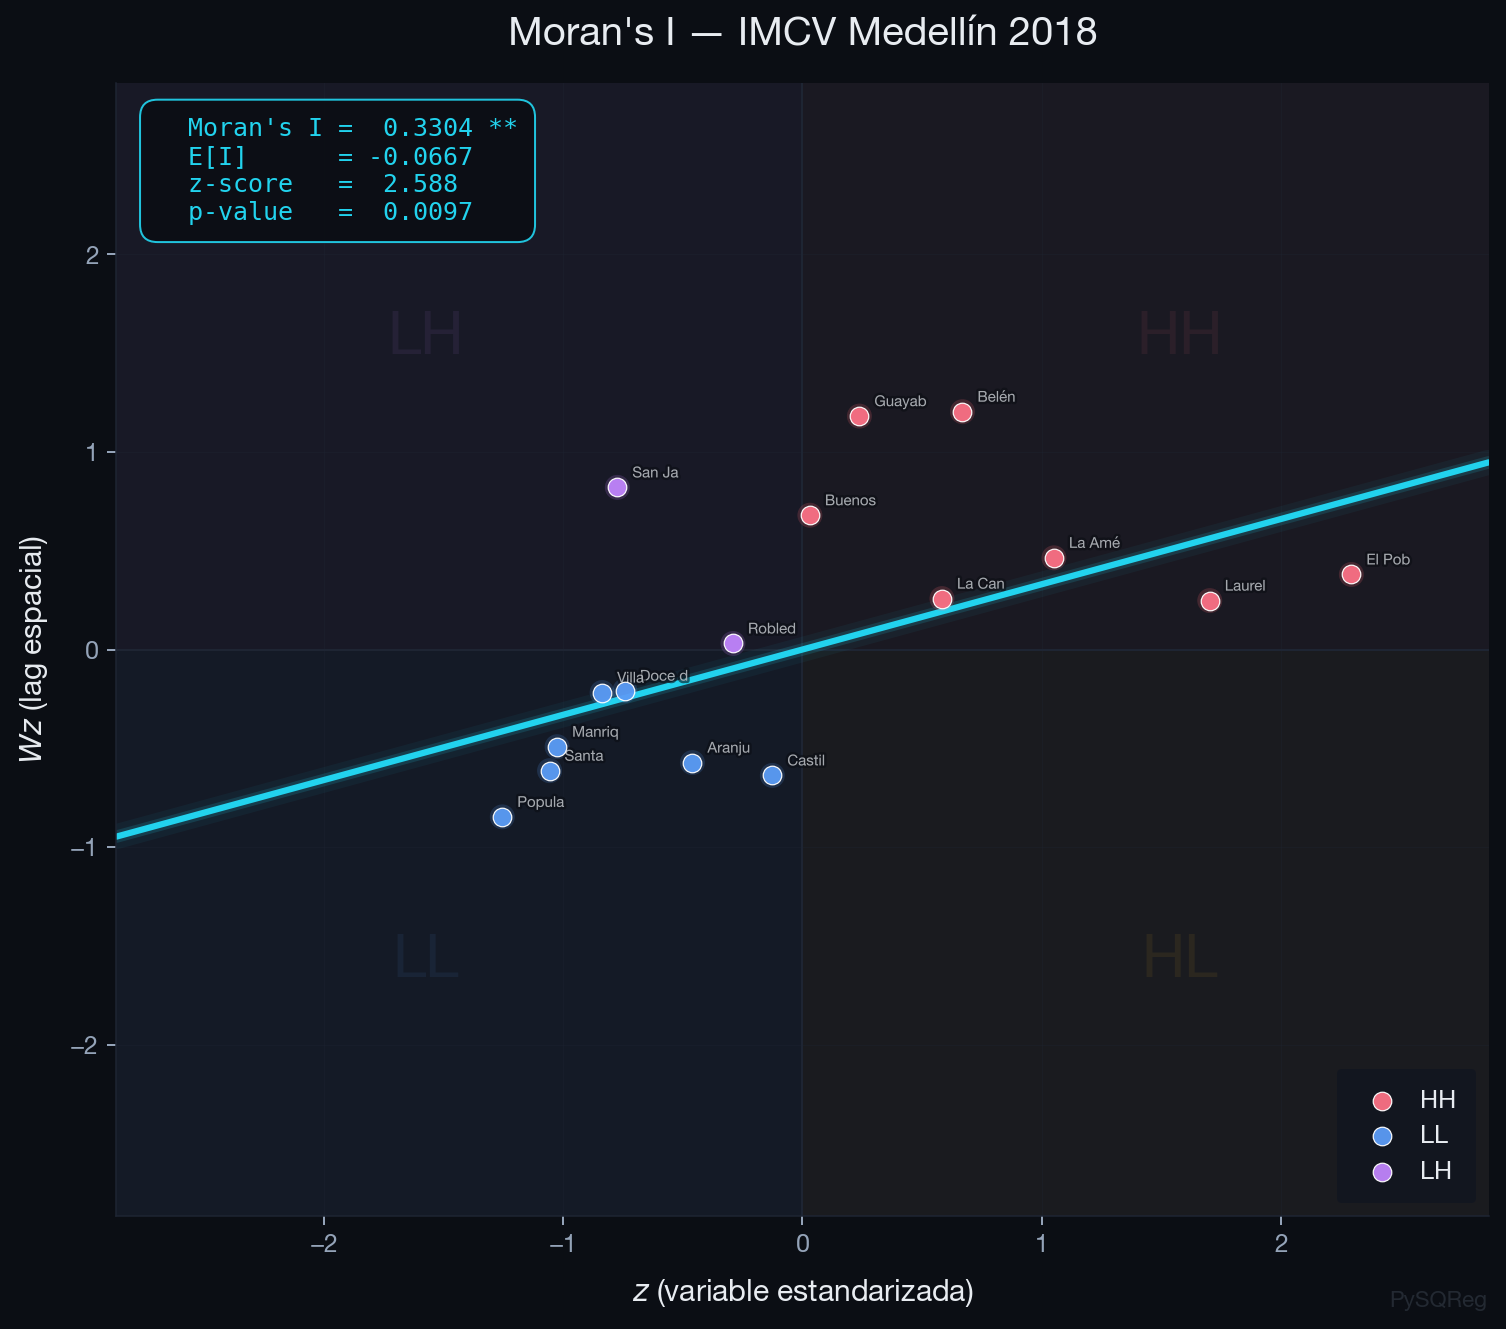

In [80]:
# ── Moran scatterplot — premium dark ──
from scipy.stats import linregress

y_arr = y.copy()
z = (y_arr - y_arr.mean()) / y_arr.std(ddof=0)
Wz = W @ z

fig, ax = plt.subplots(figsize=(8.5, 7.5), facecolor=BG)
ax.set_facecolor(CARD)

# Cuadrantes
lim = max(np.abs(z).max(), np.abs(Wz).max()) * 1.25
masks = {
    'HH': (z >= 0) & (Wz >= 0), 'LL': (z < 0) & (Wz < 0),
    'LH': (z < 0) & (Wz >= 0), 'HL': (z >= 0) & (Wz < 0),
}
fills = {
    'HH': ([0, lim, lim, 0], [0, 0, lim, lim]),
    'LH': ([-lim, 0, 0, -lim], [0, 0, lim, lim]),
    'LL': ([-lim, 0, 0, -lim], [-lim, -lim, 0, 0]),
    'HL': ([0, lim, lim, 0], [-lim, -lim, 0, 0]),
}
for q, (xs, ys) in fills.items():
    ax.fill(xs, ys, color=quad_colors[q], alpha=0.035)

ax.axhline(0, color=EDGE, lw=0.8, zorder=1)
ax.axvline(0, color=EDGE, lw=0.8, zorder=1)

# Scatter con glow + sombra
for q, m in masks.items():
    if m.any():
        # Shadow layer
        ax.scatter(z[m], Wz[m], c='black', s=100, alpha=0.15,
                   edgecolors='none', zorder=2)
        # Outer glow
        ax.scatter(z[m], Wz[m], c=quad_colors[q], s=100, alpha=0.2,
                   edgecolors='none', zorder=3)
        # Core dot
        ax.scatter(z[m], Wz[m], c=quad_colors[q], s=55, alpha=0.95,
                   edgecolors='white', linewidths=0.5, zorder=4, label=q)

# Labels por comuna
for i, row_data in df_geo.iterrows():
    ax.annotate(
        row_data['Nombre_Comuna'][:6], (z[i], Wz[i]),
        fontsize=6, color=FG, alpha=0.6,
        textcoords='offset points', xytext=(6, 4),
        path_effects=[pe.withStroke(linewidth=2, foreground=BG)],
    )

# Línea de regresión con glow
slope = float(z @ Wz) / float(z @ z)
xs_line = np.array([-lim, lim])
glow(ax, xs_line, slope * xs_line, CYAN, lw=2.5)

# Stats box — premium
res = moran_test(y_arr, W)
sig = '***' if res.p_value < 0.001 else '**' if res.p_value < 0.01 else '*' if res.p_value < 0.05 else ''
box_text = (f"  Moran's I = {res.I: .4f} {sig}\n"
            f"  E[I]      = {res.EI: .4f}\n"
            f"  z-score   = {res.z: .3f}\n"
            f"  p-value   = {res.p_value: .4f}")
ax.text(0.03, 0.97, box_text, transform=ax.transAxes, fontsize=10,
        va='top', fontfamily='monospace', color=CYAN,
        bbox=dict(boxstyle='round,pad=0.7', fc=BG, ec=CYAN, alpha=0.92,
                  linewidth=0.8))

# Quadrant watermarks
kw = dict(fontsize=24, fontweight='black', alpha=0.08, ha='center', va='center')
ax.text(lim*0.55, lim*0.55, 'HH', color=RED, **kw)
ax.text(-lim*0.55, lim*0.55, 'LH', color=PURPLE, **kw)
ax.text(-lim*0.55, -lim*0.55, 'LL', color=ACCENT, **kw)
ax.text(lim*0.55, -lim*0.55, 'HL', color=ORANGE, **kw)

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r'$z$ (variable estandarizada)', fontsize=12, labelpad=8)
ax.set_ylabel(r'$Wz$ (lag espacial)', fontsize=12, labelpad=8)
ax.set_title("Moran's I — IMCV Medellín 2018",
             fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95,
          borderpad=0.8, handletextpad=0.5)
watermark(fig)
plt.tight_layout()
plt.show()

## 6. Regresión cuantil espacial (SAR)

Modelo: `IMCV = ρ·W·IMCV + β₁·Escolaridad + β₂·Salud + β₃·Ingresos + β₄·Seguridad + ε`

In [81]:
# Variables explicativas
X_vars = ['decescolaridad', 'decsalud', 'decingresos', 'declibertadseguridad']
X = df_geo[X_vars]

print('Variables:')
print(f'  y: decimcv (Índice Multidimensional Calidad de Vida)')
for v in X_vars:
    print(f'  X: {v}')

Variables:
  y: decimcv (Índice Multidimensional Calidad de Vida)
  X: decescolaridad
  X: decsalud
  X: decingresos
  X: declibertadseguridad


In [82]:
# Mediana (tau=0.5) — Two-stage
model_50 = QuantSAR(tau=0.5, method='two_stage', nboot=500, random_state=42)
model_50.fit(X, y, W)
model_50.summary()

Kim & Muller Two-Stage Quantile Regression
Quantile: tau = 0.5
1. MODEL COEFFICIENTS
---------------------------------------------------------------------------
                        Coef.  Bootstrap SE  Z-values  Pr(>|z|)
(Intercept)          -7.01834      25.10824  -0.27952   0.77984
decescolaridad       -5.86632       7.83669  -0.74857   0.45412
decsalud              9.59301      14.13995   0.67843   0.49750
decingresos          19.77436      15.63858   1.26446   0.20606
declibertadseguridad  1.22211      10.25502   0.11917   0.90514
WY                   -0.08461       0.22867  -0.37003   0.71136

2. SPATIAL IMPACTS (LeSage & Pace)
---------------------------------------------------------------------------
                       Direct  SE Direct  Indirect (Spillover)  SE Indirect  p-val Indirect    Total  SE Total
decescolaridad       -5.89363    8.92994               0.48495      9.92397         0.96103 -5.40867  15.10230
decsalud              9.63766   23.52798              -0.

,Coef.,Bootstrap SE,Z-values,Pr(>|z|)
(Intercept),-7.018345,25.108241,-0.279524,0.779843
decescolaridad,-5.866322,7.836688,-0.748572,0.454115
decsalud,9.593012,14.139945,0.678433,0.497497
decingresos,19.774355,15.638577,1.264460,0.206065
declibertadseguridad,1.222115,10.255022,0.119172,0.905139
WY,-0.084614,0.228670,-0.370027,0.711362


In [83]:
# Cuantil bajo (tau=0.25) — comunas más vulnerables
model_25 = QuantSAR(tau=0.25, method='two_stage', nboot=500, random_state=42)
model_25.fit(X, y, W)
model_25.summary()

Kim & Muller Two-Stage Quantile Regression
Quantile: tau = 0.25
1. MODEL COEFFICIENTS
---------------------------------------------------------------------------
                         Coef.  Bootstrap SE  Z-values  Pr(>|z|)
(Intercept)          -14.55960      32.94375  -0.44195   0.65852
decescolaridad        -3.83352       8.87411  -0.43199   0.66575
decsalud              11.98016      14.77742   0.81071   0.41753
decingresos           15.96503      16.74428   0.95346   0.34036
declibertadseguridad   0.09096      13.25842   0.00686   0.99453
WY                    -0.02886       0.24248  -0.11902   0.90526

2. SPATIAL IMPACTS (LeSage & Pace)
---------------------------------------------------------------------------
                       Direct  SE Direct  Indirect (Spillover)  SE Indirect  p-val Indirect    Total  SE Total
decescolaridad       -3.83826    9.05361               0.11227      3.77957         0.97630 -3.72599  10.91522
decsalud             11.99496   15.77938         

,Coef.,Bootstrap SE,Z-values,Pr(>|z|)
(Intercept),-14.559595,32.943752,-0.441953,0.658523
decescolaridad,-3.833522,8.874114,-0.431989,0.665749
decsalud,11.980159,14.777424,0.810707,0.417534
decingresos,15.965028,16.744282,0.953461,0.340356
declibertadseguridad,0.090955,13.258420,0.006860,0.994526
WY,-0.028859,0.242478,-0.119019,0.905260


In [84]:
# Cuantil alto (tau=0.75) — comunas con mejor calidad de vida
model_75 = QuantSAR(tau=0.75, method='two_stage', nboot=500, random_state=42)
model_75.fit(X, y, W)
model_75.summary()

Kim & Muller Two-Stage Quantile Regression
Quantile: tau = 0.75
1. MODEL COEFFICIENTS
---------------------------------------------------------------------------
                        Coef.  Bootstrap SE  Z-values  Pr(>|z|)
(Intercept)          -6.98111      28.16783  -0.24784   0.80426
decescolaridad       -5.48976       7.09470  -0.77378   0.43906
decsalud              8.62435      16.19095   0.53266   0.59427
decingresos          20.02873      16.79811   1.19232   0.23314
declibertadseguridad  1.98056      10.24249   0.19337   0.84667
WY                   -0.06978       0.25888  -0.26956   0.78750

2. SPATIAL IMPACTS (LeSage & Pace)
---------------------------------------------------------------------------
                       Direct  SE Direct  Indirect (Spillover)  SE Indirect  p-val Indirect    Total  SE Total
decescolaridad       -5.50960   10.01064               0.37794      8.02186         0.96242 -5.13166  10.38310
decsalud              8.65552   42.71083              -0

,Coef.,Bootstrap SE,Z-values,Pr(>|z|)
(Intercept),-6.981105,28.167834,-0.247840,0.804258
decescolaridad,-5.489765,7.094704,-0.773783,0.439059
decsalud,8.624350,16.190946,0.532665,0.594266
decingresos,20.028730,16.798114,1.192320,0.233136
declibertadseguridad,1.980565,10.242487,0.193368,0.846671
WY,-0.069783,0.258877,-0.269563,0.787497


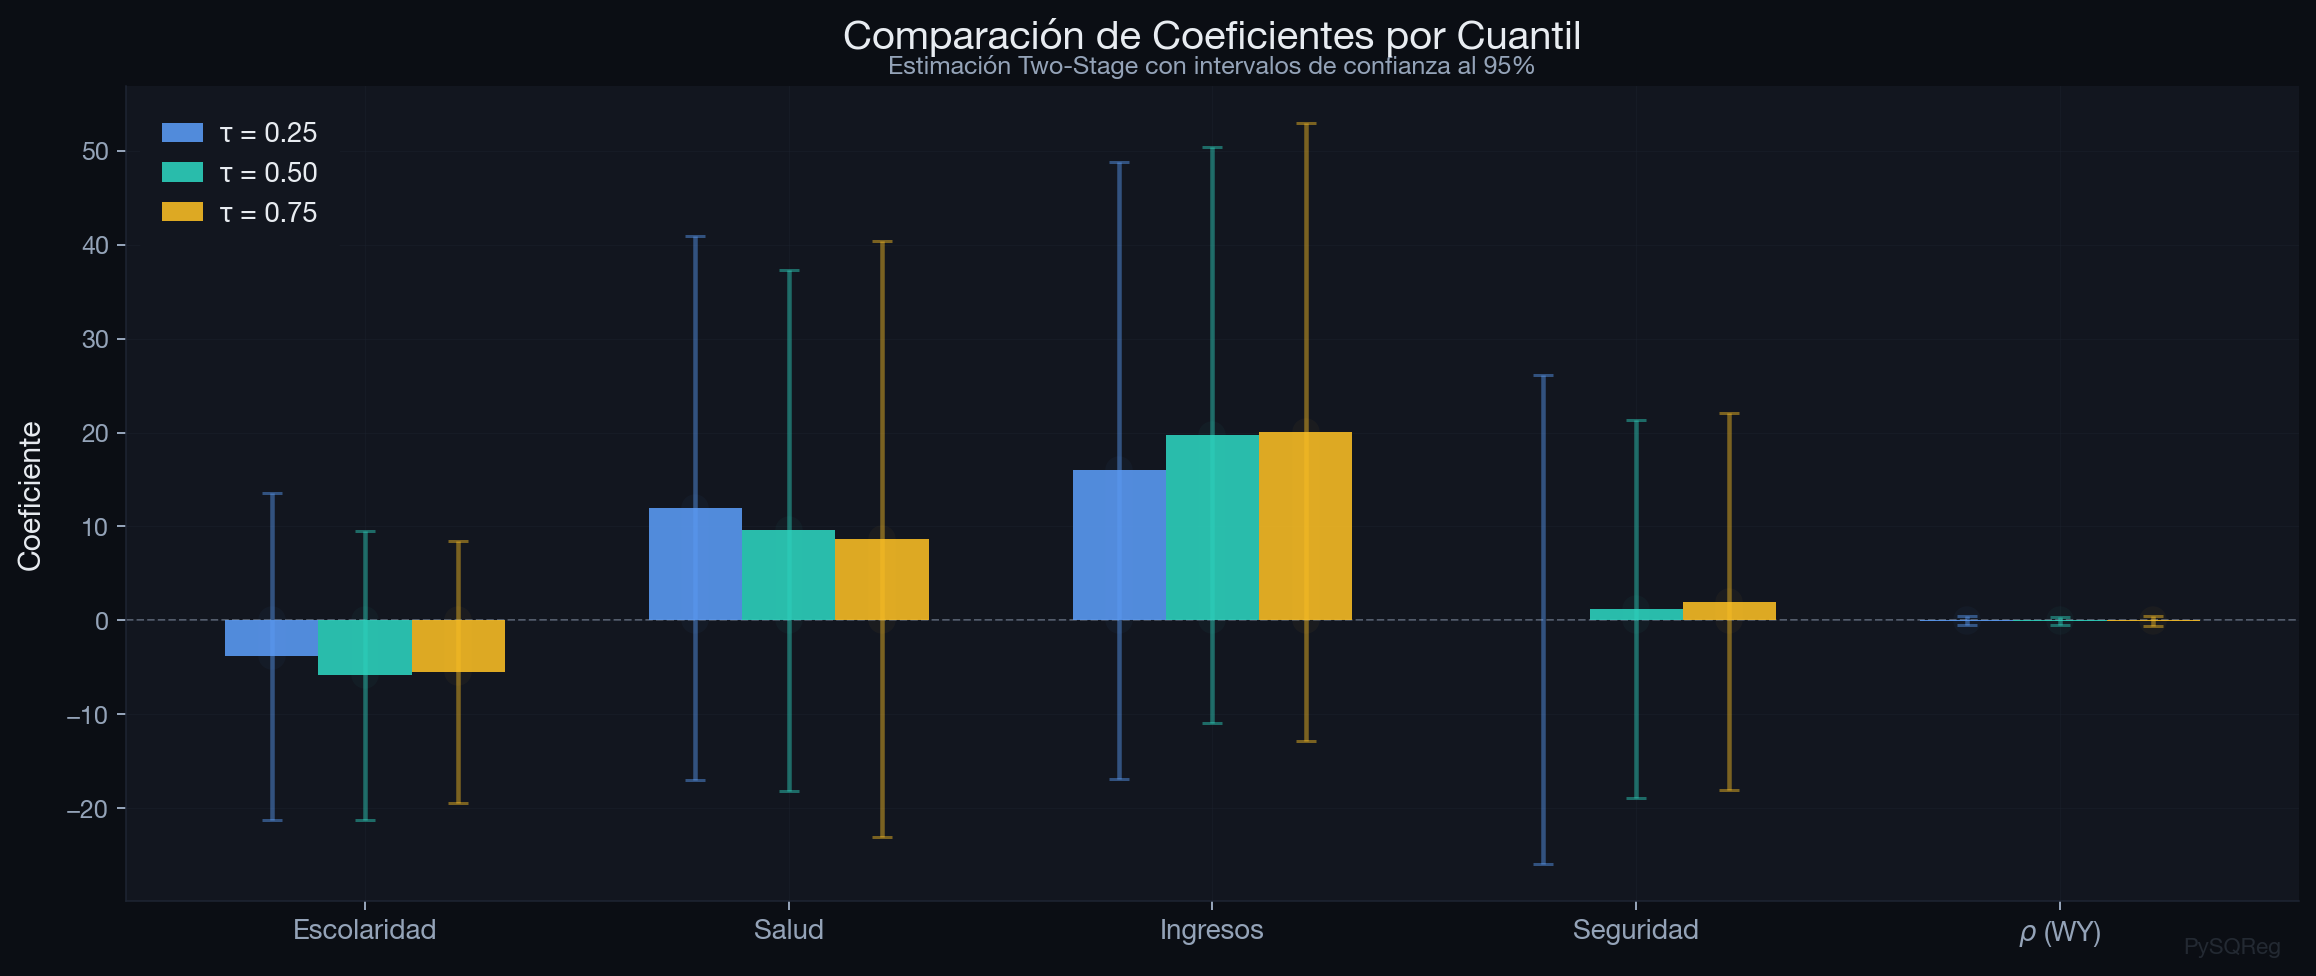

In [85]:
# ── Comparación visual de coeficientes por cuantil — premium ──
models = {'τ = 0.25': model_25, 'τ = 0.50': model_50, 'τ = 0.75': model_75}
var_names = X_vars + ['WY (ρ)']
nice_names = ['Escolaridad', 'Salud', 'Ingresos', 'Seguridad', r'$\rho$ (WY)']

fig, ax = plt.subplots(figsize=(13, 5.5), facecolor=BG)
ax.set_facecolor(CARD)

x_pos = np.arange(len(var_names))
width = 0.22
colors = [ACCENT, TEAL, ORANGE]

for i, (label, mdl) in enumerate(models.items()):
    coefs = np.append(mdl.coef_, mdl.rho_)
    ses = np.append(mdl.se_[1:-1], mdl.se_[-1])
    
    # Bars con glow sutil
    bars = ax.bar(x_pos + i * width, coefs, width, label=label,
                  color=colors[i], alpha=0.88, edgecolor='none',
                  zorder=3)
    # Glow detrás de cada barra
    for bar in bars:
        x_b = bar.get_x() + bar.get_width() / 2
        y_b = bar.get_height()
        ax.plot([x_b, x_b], [0, y_b], color=colors[i], lw=width*50,
                alpha=0.04, solid_capstyle='round', zorder=2)
    
    # Error bars
    ax.errorbar(x_pos + i * width, coefs, yerr=1.96 * ses,
                fmt='none', ecolor=colors[i], alpha=0.45,
                capsize=4, lw=1.8, capthick=1.2, zorder=4)

ax.axhline(0, color=SLATE, lw=0.8, ls='--', alpha=0.5, zorder=1)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(nice_names, fontsize=11)
ax.set_ylabel('Coeficiente', fontsize=12, labelpad=8)
ax.set_title('Comparación de Coeficientes por Cuantil',
             fontsize=16, fontweight='bold', pad=15)
ax.text(0.5, 1.015, 'Estimación Two-Stage con intervalos de confianza al 95%',
        transform=ax.transAxes, ha='center', fontsize=10,
        color=SLATE, fontstyle='italic')
ax.legend(fontsize=11, loc='upper left', borderpad=0.8,
          handlelength=1.5, handletextpad=0.6)
watermark(fig)
plt.tight_layout()
plt.show()

## 7. Grid Search (Chernozhukov-Hansen)

In [86]:
from pysqreg import plot_rho_path

model_gs = QuantSAR(tau=0.5, method='grid_search')
model_gs.fit(X, y, W)
model_gs.summary()

Chernozhukov & Hansen IV Quantile Regression
Quantile: tau = 0.5
1. MODEL COEFFICIENTS
---------------------------------------------------------------------------
                        Coef.  Std. Err.  Z-Values  Pr(>|z|)
(Intercept)          -6.91009    4.87030  -1.41882   0.15595
decescolaridad       -6.01163    1.87075  -3.21348   0.00131
decsalud              9.76542    2.95222   3.30782   0.00094
decingresos          19.90533    3.14490   6.32940   0.00000
declibertadseguridad  1.02354    2.01919   0.50690   0.61222
WY                   -0.09000    0.05670  -1.58740   0.11242

2. SPATIAL IMPACTS (LeSage & Pace)
---------------------------------------------------------------------------
                       Direct  SE Direct  Indirect (Spillover)  SE Indirect  p-val Indirect    Total  SE Total
decescolaridad       -6.02305    1.87619               0.50780      0.35755         0.15554 -5.51525   1.70343
decsalud              9.78398    2.97537              -0.82488      0.69716 

,Coef.,Std. Err.,Z-Values,Pr(>|z|)
(Intercept),-6.910091,4.870297,-1.418823,1.559505e-01
decescolaridad,-6.011625,1.870752,-3.213480,1.311368e-03
decsalud,9.765419,2.952223,3.307819,9.402561e-04
decingresos,19.905329,3.144901,6.329397,2.461207e-10
declibertadseguridad,1.023537,2.019194,0.506904,6.122224e-01
WY,-0.090000,0.056696,-1.587402,1.124216e-01


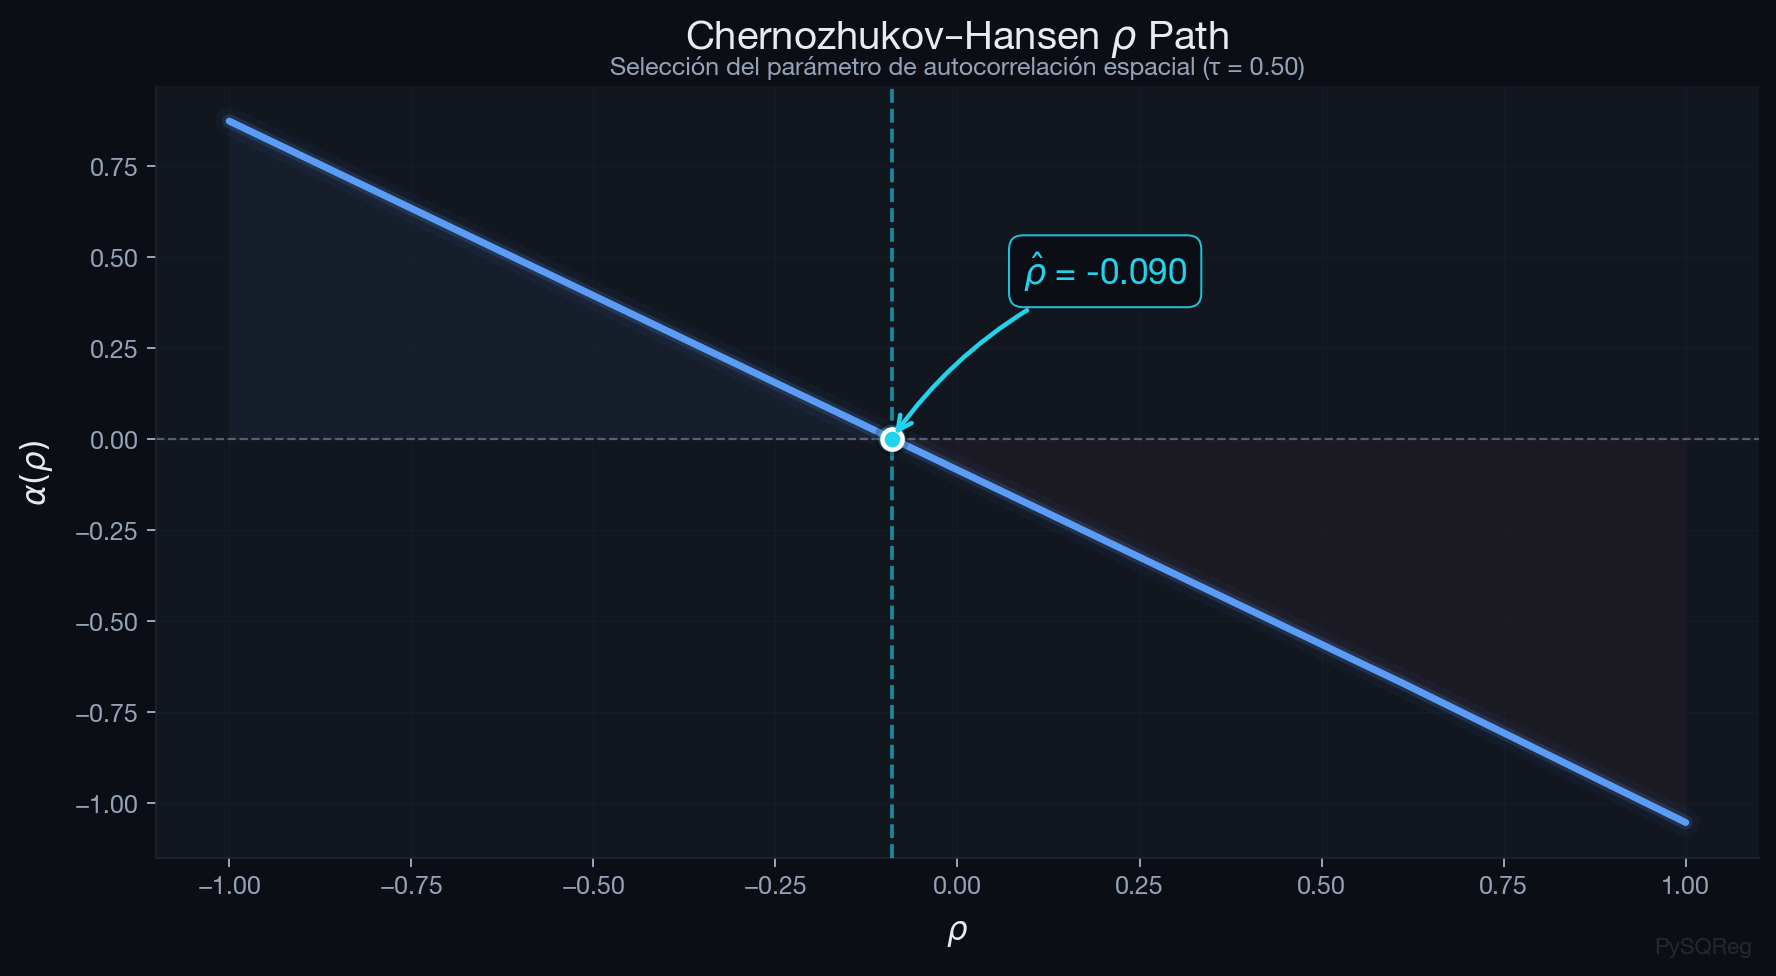

In [87]:
# ── Rho path — premium dark ──
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=BG)
ax.set_facecolor(CARD)

grid = model_gs.rho_grid_
path = model_gs.rho_path_
rho_star = model_gs.rho_
j_opt = np.argmin(np.abs(path))
alpha_star = path[j_opt]

# Gradient fill bajo la curva
ax.fill_between(grid, path, 0,
                where=(path >= 0), color=ACCENT, alpha=0.06)
ax.fill_between(grid, path, 0,
                where=(path < 0), color=RED, alpha=0.04)

# Glow line
glow(ax, grid, path, ACCENT, lw=2.8)

# Zero reference
ax.axhline(0, color=SLATE, lw=0.9, ls='--', alpha=0.5)

# Optimal rho — línea vertical + punto
ax.axvline(rho_star, color=CYAN, lw=1.5, ls='--', alpha=0.6, zorder=3)

# Punto con glow
ax.scatter([rho_star], [alpha_star], color='black', s=200, alpha=0.2,
           edgecolors='none', zorder=4)
ax.scatter([rho_star], [alpha_star], color=CYAN, s=120, alpha=0.3,
           edgecolors='none', zorder=5)
ax.scatter([rho_star], [alpha_star], color=CYAN, s=65,
           edgecolors='white', linewidths=1.8, zorder=6)

# Annotation con estilo
y_range = path.max() - path.min()
ax.annotate(
    f'$\\hat{{\\rho}}$ = {rho_star:.3f}',
    xy=(rho_star, alpha_star),
    xytext=(rho_star + 0.18, alpha_star + y_range * 0.22),
    fontsize=14, fontweight='bold', color=CYAN,
    arrowprops=dict(arrowstyle='->', color=CYAN, lw=1.8,
                    connectionstyle='arc3,rad=0.15'),
    bbox=dict(boxstyle='round,pad=0.4', fc=BG, ec=CYAN,
              alpha=0.9, linewidth=0.8),
    zorder=7,
)

ax.set_xlabel(r'$\rho$', fontsize=13, labelpad=8)
ax.set_ylabel(r'$\alpha(\rho)$', fontsize=13, labelpad=8)
ax.set_title(r'Chernozhukov–Hansen $\rho$ Path',
             fontsize=16, fontweight='bold', pad=15)
ax.text(0.5, 1.015, f'Selección del parámetro de autocorrelación espacial (τ = 0.50)',
        transform=ax.transAxes, ha='center', fontsize=10,
        color=SLATE, fontstyle='italic')
watermark(fig)
plt.tight_layout()
plt.show()

## 8. Proceso cuantílico — cómo cambian los coeficientes por cuantil

In [88]:
qp = fit_quantile_process(
    X, y, W,
    taus=np.arange(0.10, 0.91, 0.05),
    method='two_stage',
    nboot=200,
    random_state=42,
)
print(qp)

  Fitting quantile 0.90  [17/17]
QuantileProcessResult(17 quantiles, 6 variables)


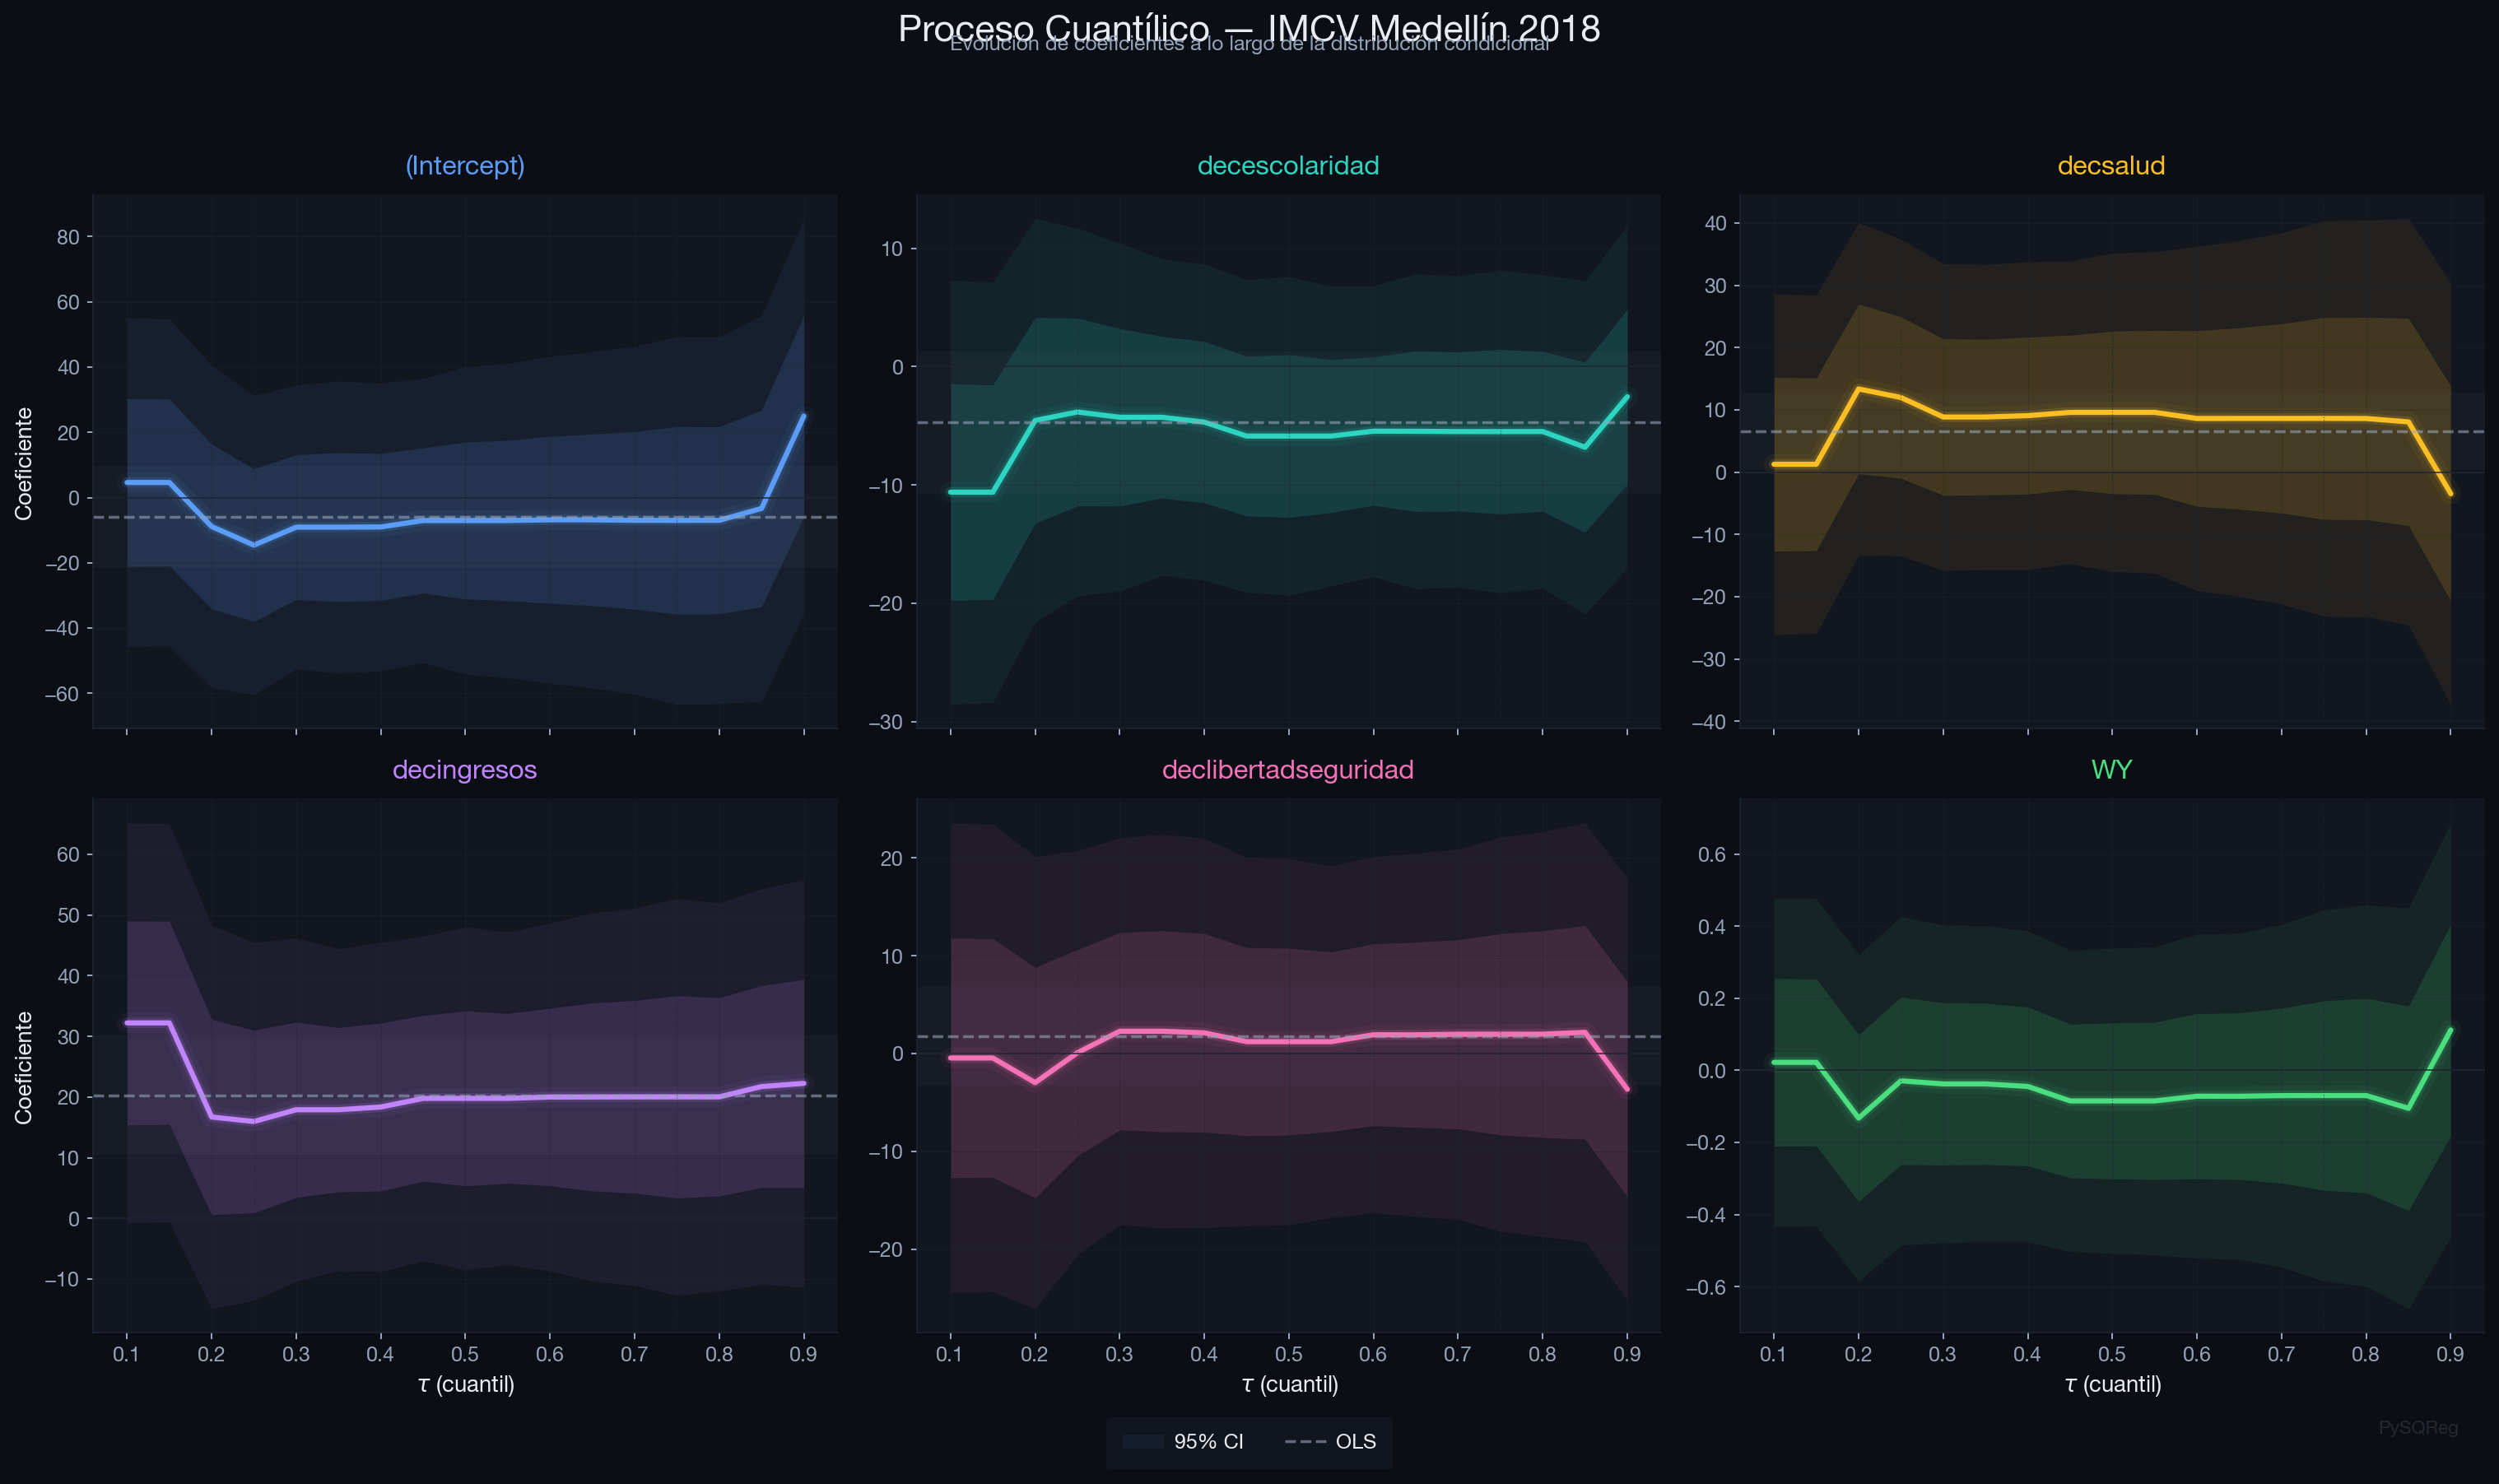

In [89]:
# ── Proceso cuantílico — premium dark ──
data = qp.data
ols = qp.ols

variables = list(data['variable'].unique())
n_vars = len(variables)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.8 * nrows),
                         facecolor=BG, sharex=True, squeeze=False)

var_colors = dict(zip(variables, PALETTE[:n_vars] + [SLATE] * n_vars))

for idx, var_name in enumerate(variables):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]
    ax.set_facecolor(CARD)

    sub = data[data['variable'] == var_name].sort_values('tau')
    taus = sub['tau'].values
    coefs = sub['coef'].values
    ses = sub['se'].values
    col = var_colors[var_name]

    # Outer CI band (95%)
    ax.fill_between(taus, coefs - 1.96*ses, coefs + 1.96*ses,
                    color=col, alpha=0.07, linewidth=0, label='95% CI')
    # Inner CI band (±1 SE)
    ax.fill_between(taus, coefs - ses, coefs + ses,
                    color=col, alpha=0.15, linewidth=0)

    # Coef line con glow
    glow(ax, taus, coefs, col, lw=2.5)

    # OLS reference
    if ols is not None:
        ols_match = ols[ols['variable'] == var_name]
        if len(ols_match):
            ols_row = ols_match.iloc[0]
            ax.axhline(ols_row['coef'], color=SLATE, lw=1.4, ls='--',
                       alpha=0.6, label='OLS', zorder=2)
            ax.axhspan(ols_row['ci_lower'], ols_row['ci_upper'],
                       color=SLATE, alpha=0.04)

    ax.axhline(0, color=EDGE, lw=0.6)
    for q in (0.25, 0.50, 0.75):
        if taus.min() <= q <= taus.max():
            ax.axvline(q, color=EDGE, lw=0.5, ls=':', alpha=0.6)

    ax.set_title(var_name, fontsize=13, fontweight='bold', color=col, pad=10)
    if r == nrows - 1:
        ax.set_xlabel(r'$\tau$ (cuantil)', fontsize=11)
    if c == 0:
        ax.set_ylabel('Coeficiente', fontsize=11)
    ax.tick_params(axis='both', which='major', length=3)

# Hide unused
for idx in range(n_vars, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].set_visible(False)

# Legend compartida
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='lower center', ncol=len(handles),
               fontsize=10, frameon=True, framealpha=0.95,
               edgecolor=EDGE, bbox_to_anchor=(0.5, -0.01),
               borderpad=0.8, handletextpad=0.5)

fig.suptitle('Proceso Cuantílico — IMCV Medellín 2018',
             fontsize=18, fontweight='bold', y=1.02, color=FG)
fig.text(0.5, 0.995, 'Evolución de coeficientes a lo largo de la distribución condicional',
         ha='center', fontsize=10, color=SLATE, fontstyle='italic')
watermark(fig)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## 9. Residuales — ¿el modelo capturó la dependencia espacial?

In [90]:
y_hat = model_50.predict(X.values, W, y)
residuals = y - y_hat

print("Moran's I en residuales del modelo SAR (tau=0.5):")
moran_resid = moran_test(residuals, W)
moran_resid.summary()

Moran's I en residuales del modelo SAR (tau=0.5):
  Moran's I Test for Spatial Autocorrelation
  Moran's I statistic :  0.023810
  Expected value E[I] : -0.066667
  Variance Var[I]     :  0.018303
  Z-score             :  0.6688
  p-value (two-sided) :  0.503644
  Assumption          : randomization
  N                   : 16
-------------------------------------------------------
  No significant spatial autocorrelation detected


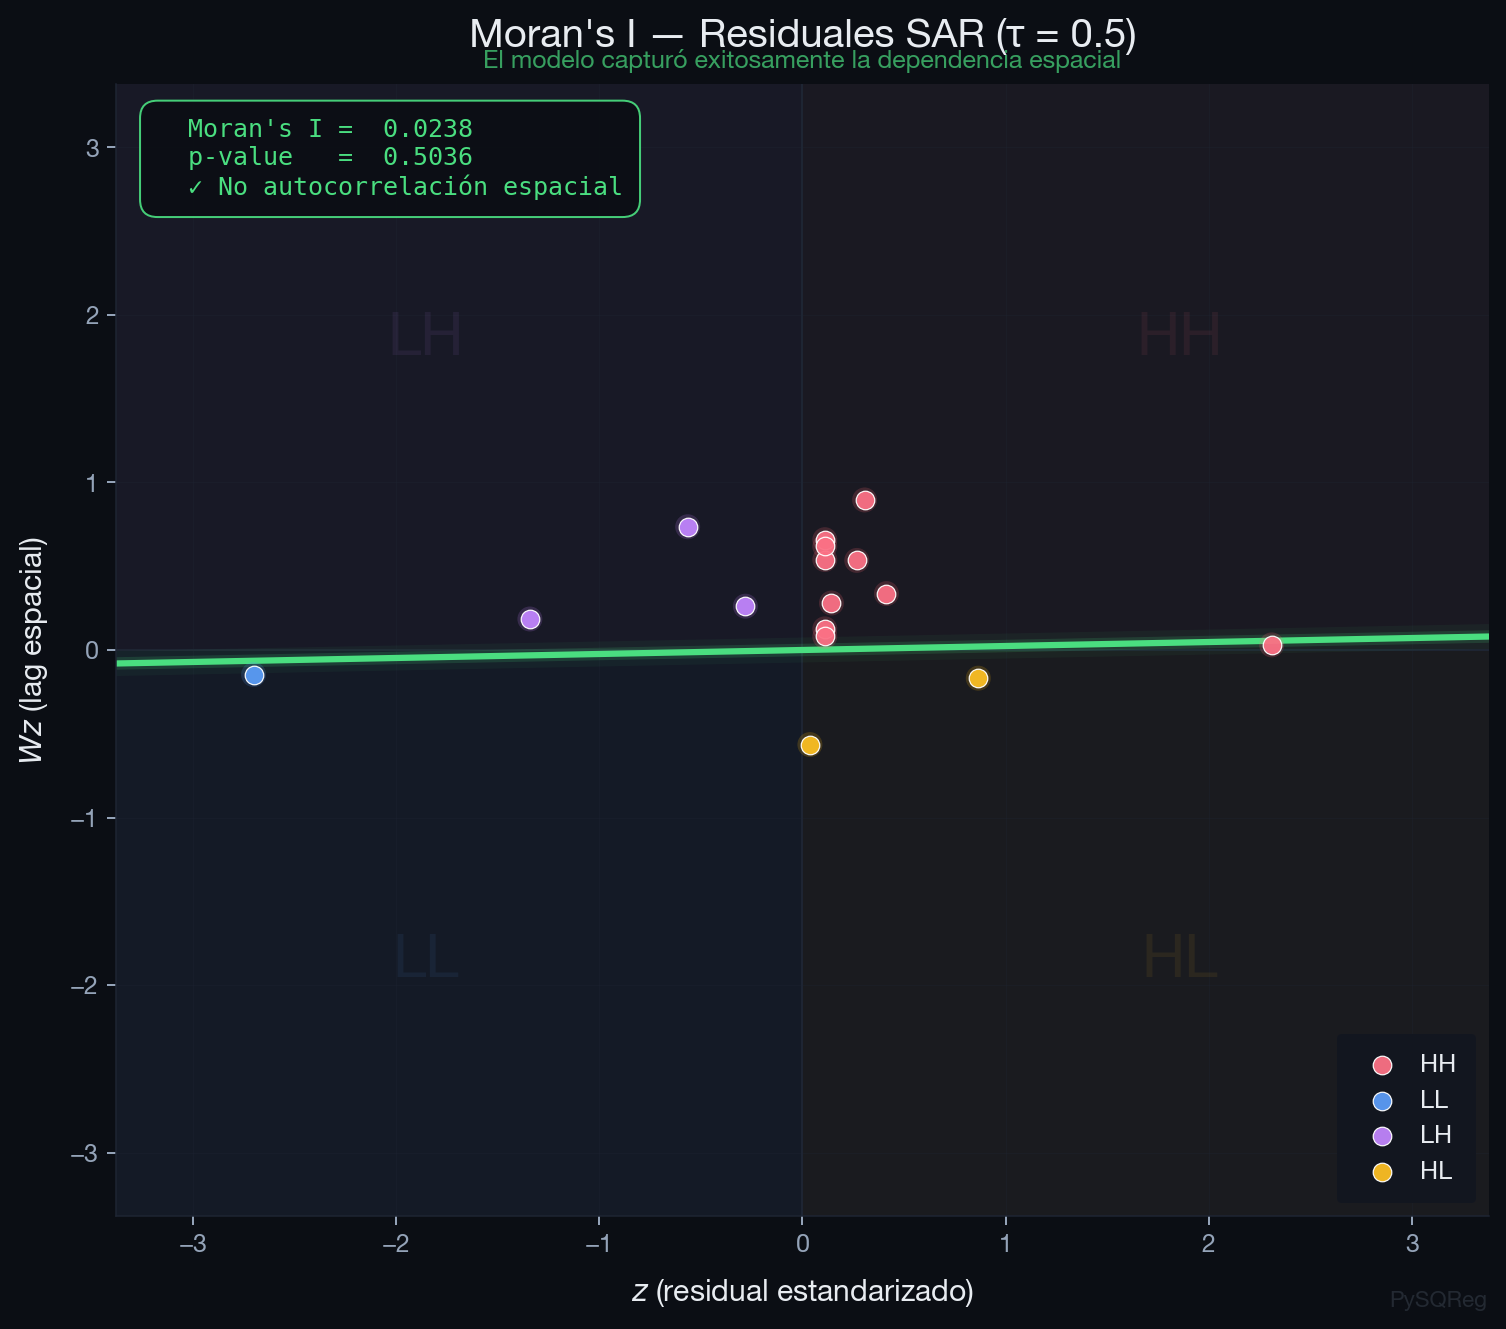

In [91]:
# ── Moran residuales — premium dark ──
z_r = (residuals - residuals.mean()) / residuals.std(ddof=0)
Wz_r = W @ z_r

fig, ax = plt.subplots(figsize=(8.5, 7.5), facecolor=BG)
ax.set_facecolor(CARD)

lim_r = max(np.abs(z_r).max(), np.abs(Wz_r).max()) * 1.25
masks_r = {
    'HH': (z_r >= 0) & (Wz_r >= 0), 'LL': (z_r < 0) & (Wz_r < 0),
    'LH': (z_r < 0) & (Wz_r >= 0), 'HL': (z_r >= 0) & (Wz_r < 0),
}
for q, (xs, ys) in {
    'HH': ([0, lim_r, lim_r, 0], [0, 0, lim_r, lim_r]),
    'LH': ([-lim_r, 0, 0, -lim_r], [0, 0, lim_r, lim_r]),
    'LL': ([-lim_r, 0, 0, -lim_r], [-lim_r, -lim_r, 0, 0]),
    'HL': ([0, lim_r, lim_r, 0], [-lim_r, -lim_r, 0, 0]),
}.items():
    ax.fill(xs, ys, color=quad_colors[q], alpha=0.035)

ax.axhline(0, color=EDGE, lw=0.8)
ax.axvline(0, color=EDGE, lw=0.8)

for q, m in masks_r.items():
    if m.any():
        ax.scatter(z_r[m], Wz_r[m], c='black', s=100, alpha=0.15,
                   edgecolors='none', zorder=2)
        ax.scatter(z_r[m], Wz_r[m], c=quad_colors[q], s=100, alpha=0.2,
                   edgecolors='none', zorder=3)
        ax.scatter(z_r[m], Wz_r[m], c=quad_colors[q], s=55, alpha=0.95,
                   edgecolors='white', linewidths=0.5, zorder=4, label=q)

slope_r = float(z_r @ Wz_r) / float(z_r @ z_r)
glow(ax, np.array([-lim_r, lim_r]), slope_r * np.array([-lim_r, lim_r]), GREEN, lw=2.5)

# Stats box with green accent (no autocorrelation = good)
res_r = moran_test(residuals, W)
box_r = (f"  Moran's I = {res_r.I: .4f}\n"
         f"  p-value   = {res_r.p_value: .4f}\n"
         f"  ✓ No autocorrelación espacial")
ax.text(0.03, 0.97, box_r, transform=ax.transAxes, fontsize=10,
        va='top', fontfamily='monospace', color=GREEN,
        bbox=dict(boxstyle='round,pad=0.7', fc=BG, ec=GREEN, alpha=0.92,
                  linewidth=0.8))

# Quadrant watermarks
kw = dict(fontsize=24, fontweight='black', alpha=0.08, ha='center', va='center')
ax.text(lim_r*0.55, lim_r*0.55, 'HH', color=RED, **kw)
ax.text(-lim_r*0.55, lim_r*0.55, 'LH', color=PURPLE, **kw)
ax.text(-lim_r*0.55, -lim_r*0.55, 'LL', color=ACCENT, **kw)
ax.text(lim_r*0.55, -lim_r*0.55, 'HL', color=ORANGE, **kw)

ax.set_xlim(-lim_r, lim_r)
ax.set_ylim(-lim_r, lim_r)
ax.set_xlabel(r'$z$ (residual estandarizado)', fontsize=12, labelpad=8)
ax.set_ylabel(r'$Wz$ (lag espacial)', fontsize=12, labelpad=8)
ax.set_title("Moran's I — Residuales SAR (τ = 0.5)",
             fontsize=16, fontweight='bold', pad=15)
ax.text(0.5, 1.015, 'El modelo capturó exitosamente la dependencia espacial',
        transform=ax.transAxes, ha='center', fontsize=10,
        color=GREEN, fontstyle='italic', alpha=0.7)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95,
          borderpad=0.8, handletextpad=0.5)
watermark(fig)
plt.tight_layout()
plt.show()

## 10. Mapa de residuales

/var/folders/t1/z9wpfgts6hg2hkzn2rwjw6q40000gn/T/ipykernel_14486/2383422958.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


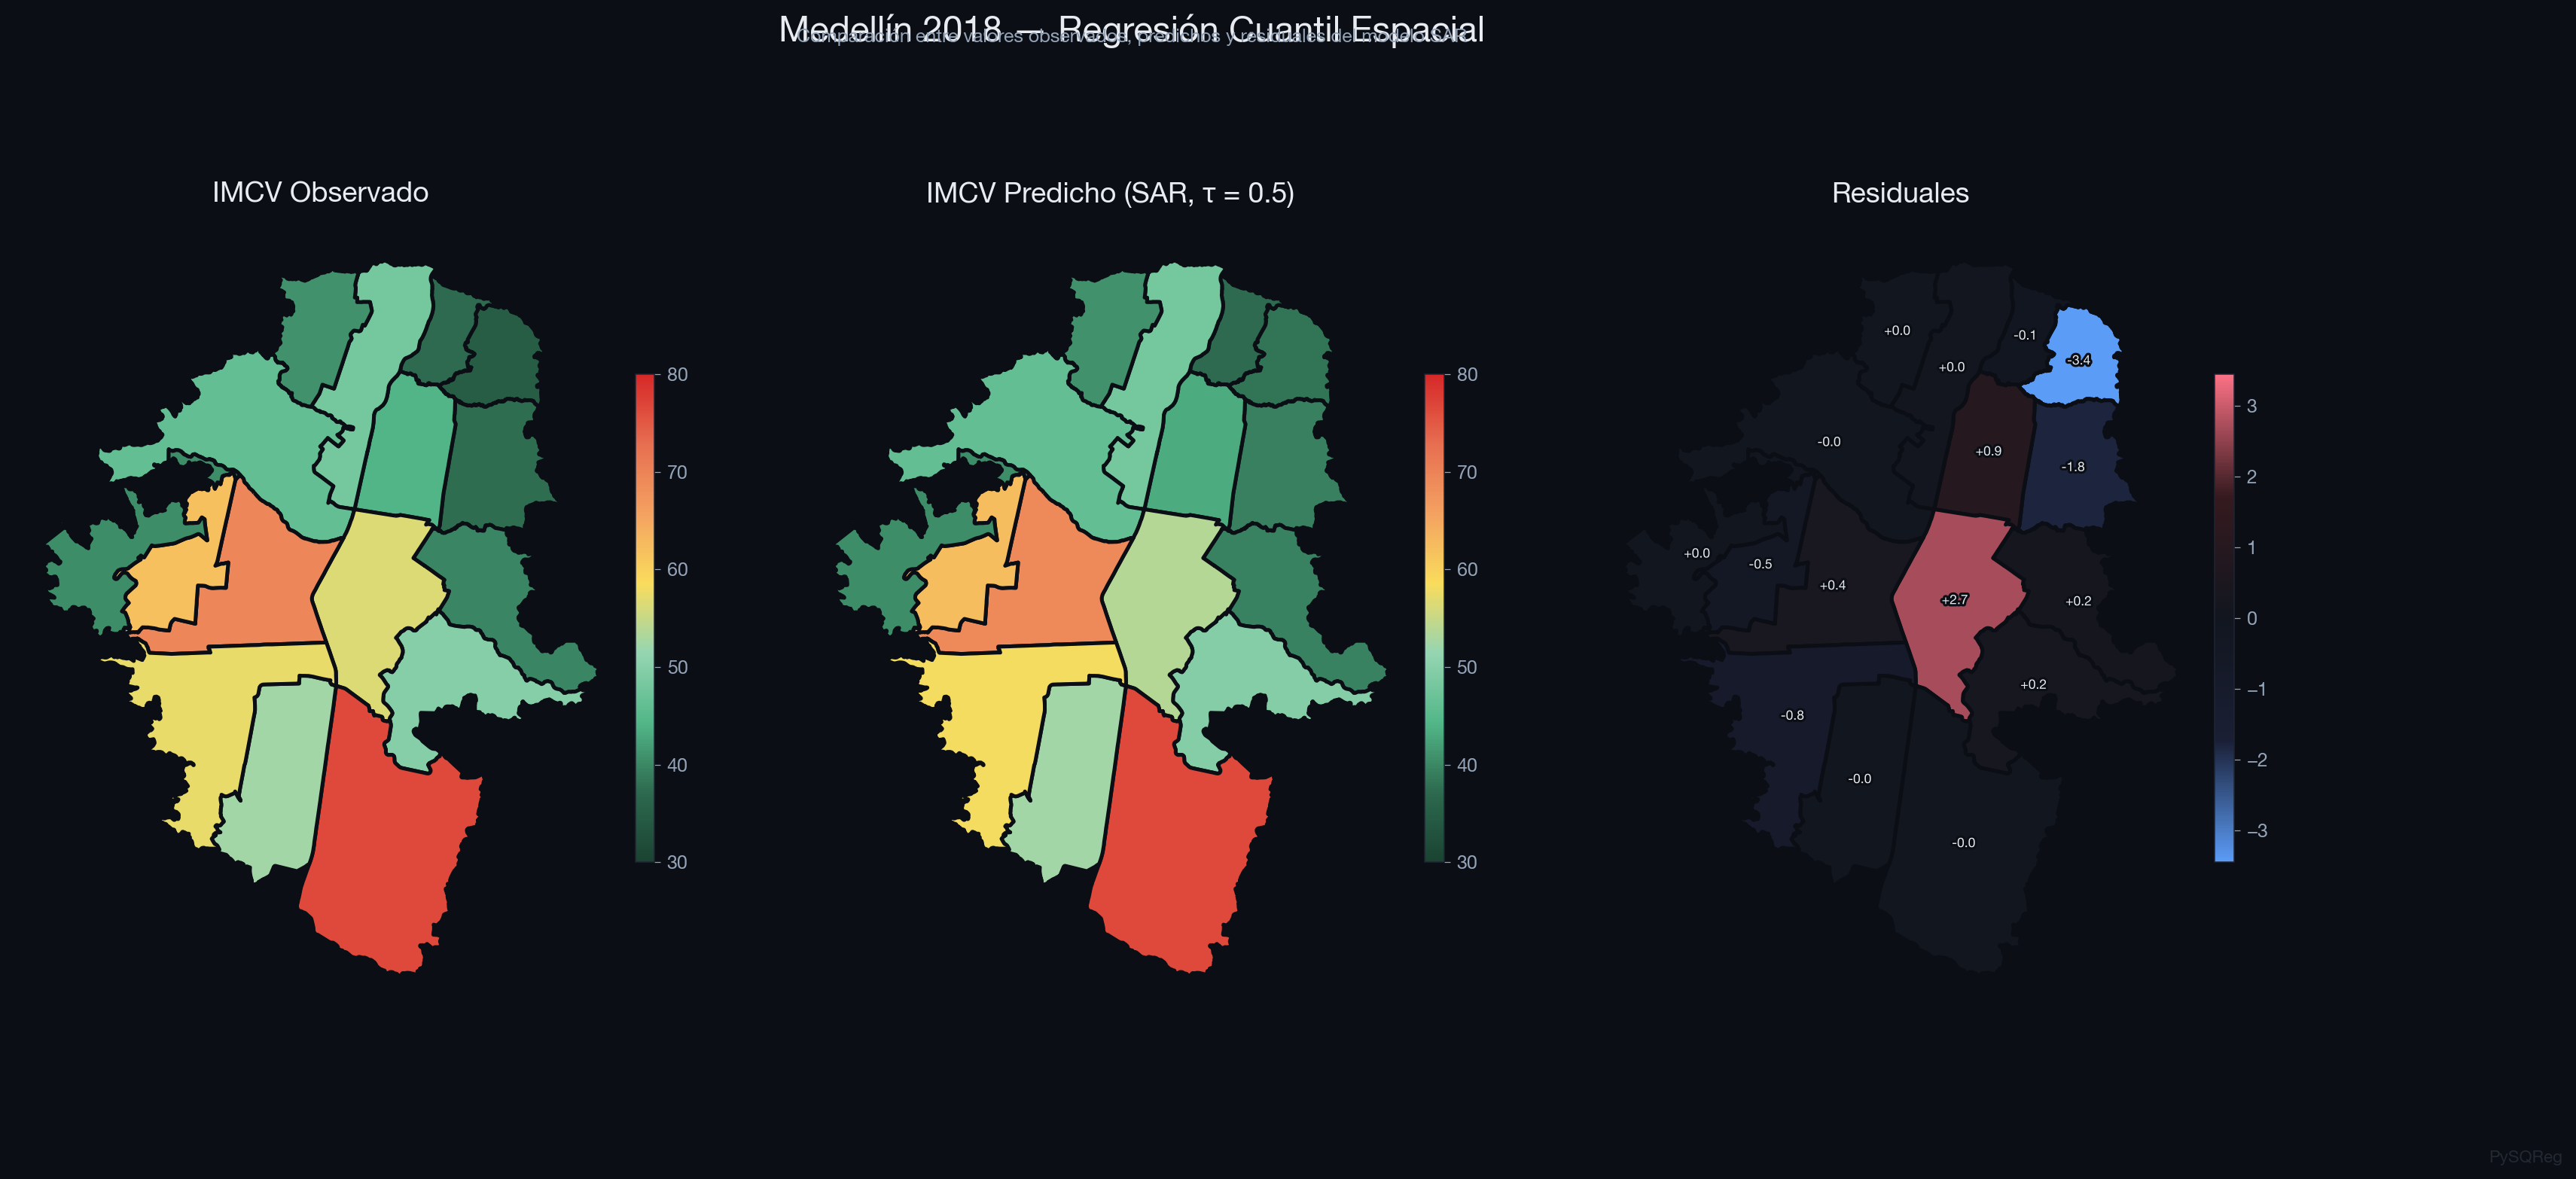

In [92]:
# ── Mapas comparativos — premium dark ──
df_geo['residuals'] = residuals
df_geo['y_hat'] = y_hat

fig, axes = plt.subplots(1, 3, figsize=(22, 8.5), facecolor=BG,
                         gridspec_kw={'wspace': 0.08})

# Palette compartida para obs/pred
cmap_obs = mcolors.LinearSegmentedColormap.from_list(
    'imcv2', ['#1B4332', '#2D6A4F', '#52B788', '#95D5B2',
              '#F9DC5C', '#F4A261', '#E76F51', '#D62828'], N=256)
norm_obs = mcolors.Normalize(vmin=30, vmax=80)

# ── Panel 1: IMCV observado ──
ax0 = axes[0]
ax0.set_facecolor(BG)
df_geo.plot(column='decimcv', cmap=cmap_obs, norm=norm_obs, ax=ax0,
            edgecolor=BG, linewidth=2)
ax0.set_title('IMCV Observado', fontsize=15, fontweight='bold', pad=12)
ax0.set_axis_off()
sm0 = plt.cm.ScalarMappable(cmap=cmap_obs, norm=norm_obs)
cb0 = fig.colorbar(sm0, ax=ax0, shrink=0.55, pad=0.01, aspect=25)
style_colorbar(cb0)

# ── Panel 2: Predicho ──
ax1 = axes[1]
ax1.set_facecolor(BG)
df_geo.plot(column='y_hat', cmap=cmap_obs, norm=norm_obs, ax=ax1,
            edgecolor=BG, linewidth=2)
ax1.set_title('IMCV Predicho (SAR, τ = 0.5)', fontsize=15, fontweight='bold', pad=12)
ax1.set_axis_off()
sm1 = plt.cm.ScalarMappable(cmap=cmap_obs, norm=norm_obs)
cb1 = fig.colorbar(sm1, ax=ax1, shrink=0.55, pad=0.01, aspect=25)
style_colorbar(cb1)

# ── Panel 3: Residuales ──
ax2 = axes[2]
ax2.set_facecolor(BG)
vmax_r = np.abs(residuals).max()
cmap_res = mcolors.LinearSegmentedColormap.from_list(
    'resid', [ACCENT, '#1A1F35', CARD, '#351A1F', RED], N=256)
norm_res = mcolors.TwoSlopeNorm(vmin=-vmax_r, vcenter=0, vmax=vmax_r)
df_geo.plot(column='residuals', cmap=cmap_res, norm=norm_res, ax=ax2,
            edgecolor=BG, linewidth=2)
ax2.set_title('Residuales', fontsize=15, fontweight='bold', pad=12)
ax2.set_axis_off()
sm2 = plt.cm.ScalarMappable(cmap=cmap_res, norm=norm_res)
cb2 = fig.colorbar(sm2, ax=ax2, shrink=0.55, pad=0.01, aspect=25)
style_colorbar(cb2)

# Labels en residuales
for _, row in df_geo.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    val = row['residuals']
    ax2.annotate(
        f'{val:+.1f}', xy=(cx, cy), ha='center', va='center',
        fontsize=7, fontweight='bold', color=FG,
        path_effects=[pe.withStroke(linewidth=2.5, foreground=BG)],
    )

fig.suptitle('Medellín 2018 — Regresión Cuantil Espacial',
             fontsize=19, fontweight='bold', y=1.02, color=FG)
fig.text(0.5, 0.995, 'Comparación entre valores observados, predichos y residuales del modelo SAR',
         ha='center', fontsize=10, color=SLATE, fontstyle='italic')
watermark(fig)
plt.tight_layout()
plt.show()

## 11. Conclusiones

### Contexto espacial de los datos

- El **IMCV varía entre 34.75 (Popular) y 76.60 (El Poblado)**, evidenciando una profunda desigualdad territorial en Medellín — la comuna más rica duplica en calidad de vida a la más pobre.
- El **test de Moran (I = 0.33, p = 0.0097)** confirma autocorrelación espacial positiva significativa: las comunas con alta (baja) calidad de vida tienden a agruparse geográficamente. Esto justifica el uso de modelos espaciales.

---

### Interpretación de los coeficientes (Grid Search, tau=0.5)

El modelo SAR estima:

$$\text{IMCV} = \rho \cdot W \cdot \text{IMCV} + \beta_0 + \beta_1 \cdot \text{Escolaridad} + \beta_2 \cdot \text{Salud} + \beta_3 \cdot \text{Ingresos} + \beta_4 \cdot \text{Seguridad} + \varepsilon$$

| Variable | Coef. | SE | p-value | Interpretación |
|---|---|---|---|---|
| **Intercepto** | -6.91 | 4.87 | 0.156 | No significativo. El IMCV base (sin covariantes) no tiene interpretación sustantiva útil. |
| **Escolaridad** | **-6.01** | 1.87 | **0.001** | Un aumento de 1 punto en el índice de escolaridad **reduce** el IMCV en ~6 puntos. Resultado contraintuitivo — ver nota abajo. |
| **Salud** | **9.77** | 2.95 | **<0.001** | Un aumento de 1 punto en el índice de salud **incrementa** el IMCV en ~9.8 puntos. La cobertura y acceso a salud es un fuerte predictor de calidad de vida. |
| **Ingresos** | **19.91** | 3.14 | **<0.001** | El predictor más fuerte: 1 punto más en ingresos se asocia con ~20 puntos más de IMCV. El ingreso es el motor dominante de la calidad de vida en Medellín. |
| **Seguridad** | 1.02 | 2.02 | 0.612 | No significativo. La libertad y seguridad no diferencia significativamente las comunas una vez controlados los otros factores. |
| **rho (WY)** | -0.09 | 0.057 | 0.112 | No significativo. El lag espacial no aporta poder explicativo adicional — la estructura espacial ya está capturada por las covariantes. |

**Nota sobre escolaridad negativa:** Este coeficiente negativo no implica que "más educación = menos calidad de vida". En el IMCV, las dimensiones están medidas como sub-índices que ya contribuyen al índice total. Al incluir escolaridad *junto con* ingresos y salud (que están altamente correlacionados con ella), el coeficiente de escolaridad absorbe el efecto residual neto: las comunas con mayor escolaridad relativa a sus ingresos tienden a tener menor IMCV, posiblemente reflejando expectativas insatisfechas o un efecto de composición. Este es un caso clásico de **multicolinealidad entre sub-índices** del mismo indicador compuesto.

---

### Diferencias entre cuantiles (Two-Stage)

| Variable | tau=0.25 (vulnerables) | tau=0.50 (mediana) | tau=0.75 (mejor CV) |
|---|---|---|---|
| Escolaridad | -3.83 | -5.87 | -5.49 |
| Salud | 11.98 | 9.59 | 8.62 |
| **Ingresos** | **15.97** | **19.77** | **20.03** |
| Seguridad | 0.09 | 1.22 | 1.98 |
| **rho** | **-0.03** | **-0.08** | **-0.07** |

**Patrones observados:**

- **Ingresos crece con el cuantil** (15.97 → 20.03): el efecto marginal del ingreso es *mayor* en las comunas de alta calidad de vida que en las vulnerables. Esto sugiere que el ingreso tiene rendimientos crecientes sobre el IMCV — en las comunas más ricas, cada peso adicional se traduce en más calidad de vida, probablemente porque la infraestructura y los servicios complementarios ya están disponibles.

- **Salud decrece con el cuantil** (11.98 → 8.62): en las comunas vulnerables (cuantil bajo), el acceso a salud tiene un impacto proporcionalmente mayor sobre la calidad de vida. Esto tiene sentido: la cobertura básica de salud genera más ganancia marginal donde es más escasa.

- **Seguridad crece con el cuantil** (0.09 → 1.98): aunque no significativo en ningún cuantil, la tendencia sugiere que la seguridad comienza a importar más cuando las necesidades básicas están cubiertas — un patrón consistente con la jerarquía de Maslow.

- **Escolaridad se profundiza** (-3.83 → -5.49): el efecto negativo (por multicolinealidad) se acentúa en comunas de mayor calidad de vida, donde las desigualdades educativas relativas pesan más.

- **rho es estable y cercano a cero** en todos los cuantiles, confirmando que la dependencia espacial es capturada por las covariantes, no por el lag.

> **Nota importante sobre inferencia:** Los errores estándar del bootstrap son muy amplios con n=16 (ningún coeficiente es significativo), por lo que estas diferencias entre cuantiles deben interpretarse como **tendencias indicativas**, no como diferencias estadísticamente confirmadas. Con un dataset más grande, el proceso cuantílico revelaría con mayor precisión si estos patrones son robustos.

---

### Interpretación de los impactos espaciales (LeSage & Pace)

En un modelo SAR, un cambio en $X_i$ no solo afecta a $y_i$ directamente, sino que se propaga a través de la red espacial. Los impactos de LeSage & Pace descomponen el efecto total:

$$\frac{\partial y}{\partial X} = (I - \rho W)^{-1} \beta$$

| Tipo de impacto | Definición | Ejemplo con Ingresos (GS, tau=0.5) |
|---|---|---|
| **Directo** | Efecto de $X_i$ sobre $y_i$ (incluye retroalimentación vía vecinos que vuelve a $i$) | **19.94** — casi idéntico al coef. porque rho ≈ 0 |
| **Indirecto (spillover)** | Efecto de $X_i$ sobre $y_j$ para $j \neq i$ (el cambio en una comuna afecta a las vecinas) | **-1.68** (p=0.08) — marginalmente significativo |
| **Total** | Directo + Indirecto | **18.26** |

**¿Por qué los spillovers son negativos si rho es negativo?**

Con $\rho = -0.09$, el multiplicador espacial $(I - \rho W)^{-1}$ genera un efecto indirecto *opuesto* al directo. Esto significa que si una comuna mejora sus ingresos, sus vecinas experimentan una leve presión negativa sobre su IMCV — un patrón interpretable como **competencia espacial** más que cooperación: los recursos que fluyen hacia una comuna podrían estar redistribuyéndose desde las vecinas.

Sin embargo, dado que rho no es significativo, estos spillovers son **económicamente pequeños** (< 10% del efecto directo) y **estadísticamente débiles**. En la práctica, el efecto dominante es el directo.

**Comparación de impactos por cuantil (Two-Stage):**

| Variable | Directo (0.25) | Directo (0.50) | Directo (0.75) | Spillover (0.50) |
|---|---|---|---|---|
| Escolaridad | -3.84 | -5.89 | -5.51 | +0.48 |
| Salud | 12.00 | 9.64 | 8.66 | -0.79 |
| Ingresos | 15.98 | 19.87 | 20.10 | -1.63 |
| Seguridad | 0.09 | 1.23 | 1.99 | -0.10 |

Los impactos directos son prácticamente iguales a los coeficientes (porque rho ≈ 0), y los spillovers son pequeños en todos los casos. Esto confirma que **en este dataset, la dependencia espacial opera a través de las covariantes compartidas entre comunas vecinas, no a través del lag de la variable dependiente**.

---

### Diagnóstico de residuales

- El **Moran's I de los residuales = 0.024 (p = 0.50)**: el modelo capturó exitosamente toda la dependencia espacial, a pesar de que rho no es significativo. Esto indica que las covariantes por sí solas explican la estructura espacial del IMCV.

---

### Evaluación de PySQReg

| Funcionalidad | Estado |
|---|---|
| `QuantSAR` (two-stage) | Funciona correctamente |
| `QuantSAR` (grid search) | Funciona correctamente |
| `moran_test` | Resultados coherentes con `libpysal` |
| `plot_moran` | OK |
| `fit_quantile_process` | OK — 17 cuantiles sin errores |
| `plot_rho_path` | OK |
| Impactos espaciales (LeSage & Pace) | Se calculan correctamente |
| Manejo de DataFrames con nombres | OK |

| Aspecto | Two-Stage (bootstrap) | Grid Search (analítico) |
|---|---|---|
| **rho** | -0.085 (no sig.) | -0.090 (no sig.) |
| **Inferencia** | SEs muy amplios (n=16 + bootstrap) | SEs precisos, 3 variables significativas |
| **Mejor para** | Muestras grandes | Muestras pequeñas como esta |

**Limitaciones identificadas para mejorar:**

1. **n pequeño + bootstrap**: el paquete debería emitir un warning cuando n < 30 y se usa bootstrap, sugiriendo `method='grid_search'` con inferencia analítica.
2. **Convergencia en extremos**: algunos cuantiles extremos con muestras pequeñas pueden no converger — el `fit_quantile_process` los maneja silenciosamente (bien).
3. **Oportunidad**: considerar agregar soporte para matrices de pesos de `libpysal` directamente (tipo `W` object), sin necesidad de convertir a `full()` manualmente.
